## Setup

In [1]:
!pip install -q xarray dask zarr numpy scipy streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 40.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Pipeline — Load, Preprocess, Normalize → Zarr Cache

In [ ]:
import xarray as xr
import numpy as np
import glob
import os
import pandas as pd
import gc # Garbage collector for clearing RAM
import shutil # For removing directories

# --- 1. PATHS AND CONFIGURATION ---
RAIN_DIR = '/content/drive/MyDrive/isro_climate_dataset/Rainfall/'
MAXT_DIR = '/content/drive/MyDrive/isro_climate_dataset/Maxtemp/'
MINT_DIR = '/content/drive/MyDrive/isro_climate_dataset/Mintemp/'
# Modified to save directly to Google Drive
LOCAL_ZARR_PATH = '/content/drive/MyDrive/climate_twin_cache.zarr'
CLIMATOLOGY_ZARR_PATH = '/content/drive/MyDrive/climate_twin_climatology.zarr' # New path for climatology

# Grid Dimensions
RAIN_LAT_DIM, RAIN_LON_DIM = 135, 129
lat_rain = np.linspace(6.5, 38.5, RAIN_LAT_DIM)
lon_rain = np.linspace(66.5, 100.5, RAIN_LON_DIM)

TEMP_LAT_DIM, TEMP_LON_DIM = 31, 31
lat_temp = np.linspace(7.5, 37.5, TEMP_LAT_DIM)
lon_temp = np.linspace(67.5, 97.5, TEMP_LON_DIM)

rain_files = sorted(glob.glob(os.path.join(RAIN_DIR, '*.grd')))
# Corrected glob patterns for MaxTemp and MinTemp based on file naming and extension
maxt_files = sorted(glob.glob(os.path.join(MAXT_DIR, 'Maxtemp_MaxT_*.GRD')))
mint_files = sorted(glob.glob(os.path.join(MINT_DIR, '*.GRD')))

num_years = len(rain_files)
start_year = 1986

def load_and_regrid_single_year(year_idx):
    """Loads a single year, reshapes, and regrids temperature to match rainfall."""

    # Load raw binary arrays
    # -1 allows NumPy to automatically deduce 365 or 366 days (leap years)
    rain_arr = np.fromfile(rain_files[year_idx], dtype=np.float32).reshape(-1, RAIN_LAT_DIM, RAIN_LON_DIM)
    maxt_arr = np.fromfile(maxt_files[year_idx], dtype=np.float32).reshape(-1, TEMP_LAT_DIM, TEMP_LON_DIM)
    mint_arr = np.fromfile(mint_files[year_idx], dtype=np.float32).reshape(-1, TEMP_LAT_DIM, TEMP_LON_DIM)

    # Apply nan_to_num immediately after loading raw data
    rain_arr = np.nan_to_num(rain_arr, nan=0.0, posinf=0.0, neginf=0.0)
    maxt_arr = np.nan_to_num(maxt_arr, nan=0.0, posinf=0.0, neginf=0.0)
    mint_arr = np.nan_to_num(mint_arr, nan=0.0, posinf=0.0, neginf=0.0)

    # The shape from reshape will be (days, lat, lon). `days_in_year` should be just the number of days.
    days_in_year = rain_arr.shape[0]
    current_year = start_year + year_idx
    time_index = pd.date_range(start=f'{current_year}-01-01', periods=days_in_year, freq='D')

    # Wrap in xarray
    da_rain = xr.DataArray(rain_arr, coords=[time_index, lat_rain, lon_rain], dims=['time', 'lat', 'lon'], name='rainfall')
    da_maxt = xr.DataArray(maxt_arr, coords=[time_index, lat_temp, lon_temp], dims=['time', 'lat', 'lon'], name='max_temp')
    da_mint = xr.DataArray(mint_arr, coords=[time_index, lat_temp, lon_temp], dims=['time', 'lat', 'lon'], name='min_temp')

    # Regrid temperatures to match rainfall 0.25 deg grid
    # Changed method from 'bilinear' to 'linear' for multidimensional interpolation in xarray
    da_maxt_regridded = da_maxt.interp(lat=lat_rain, lon=lon_rain, method='linear')
    da_mint_regridded = da_mint.interp(lat=lat_rain, lon=lon_rain, method='linear')

    ds = xr.merge([da_rain, da_maxt_regridded, da_mint_regridded])

    # Apply log transform to rainfall immediately
    ds['rainfall'] = np.log1p(ds['rainfall'].clip(min=0))

    return ds, days_in_year

# =========================================================
# PASS 1: INCREMENTAL CLIMATOLOGY (Low RAM) With Batch Processing
# =========================================================
print("Starting Pass 1: Calculating 40-year statistics...")

# Initialize accumulators
sum_ds = None
sum_sq_ds = None
total_days = 0

BATCH_YEARS = 6 # Process 6 years at once, as requested

for batch_start in range(0, num_years, BATCH_YEARS):
    batch_end = min(batch_start + BATCH_YEARS, num_years)

    print(f"  Calculating stats for Years {start_year + batch_start} - {start_year + batch_end - 1}...")

    batch_datasets_for_concat = []
    current_batch_days = 0

    for i in range(batch_start, batch_end):
        ds_year, days = load_and_regrid_single_year(i)
        batch_datasets_for_concat.append(ds_year)
        current_batch_days += days

    ds_batch = xr.concat(batch_datasets_for_concat, dim="time")

    if sum_ds is None:
        sum_ds = ds_batch.sum(dim='time')
        sum_sq_ds = (ds_batch**2).sum(dim='time')
    else:
        sum_ds += ds_batch.sum(dim='time')
        sum_sq_ds += (ds_batch**2).sum(dim='time')

    total_days += current_batch_days

    # CLEAR RAM
    del batch_datasets_for_concat, ds_batch
    gc.collect()

# Finalize 40-year Mean and Standard Deviation
climatology_mean = sum_ds / total_days
climatology_variance = (sum_sq_ds / total_days) - (climatology_mean**2)
climatology_std = np.sqrt(climatology_variance.clip(min=0))

print("Pass 1 Complete! Climatology established.")

# Safely remove existing climatology directory before saving
if os.path.exists(CLIMATOLOGY_ZARR_PATH):
    print(f"Removing existing climatology Zarr at {CLIMATOLOGY_ZARR_PATH}")
    shutil.rmtree(CLIMATOLOGY_ZARR_PATH)

# Save climatology to a zarr file for later use in evaluation
# The evaluate_test_set function expects 'mean' and 'std' to be Zarr groups
# which themselves contain the DataArrays for 'rainfall', 'max_temp', 'min_temp'
# So, we save the climatology_mean and climatology_std Datasets to sub-groups.
climatology_mean.to_zarr(CLIMATOLOGY_ZARR_PATH + '/mean', mode='w')
climatology_std.to_zarr(CLIMATOLOGY_ZARR_PATH + '/std', mode='w')
print(f"Climatology (mean and std) saved to {CLIMATOLOGY_ZARR_PATH}")

# =========================================================
# PASS 2: NORMALIZE, SAVE & CLEAR RAM (Also with Batch Processing)
# =========================================================
print(f"Starting Pass 2: Processing and writing to Zarr at {LOCAL_ZARR_PATH}...")

for batch_start in range(0, num_years, BATCH_YEARS):
    batch_end = min(batch_start + BATCH_YEARS, num_years)

    print(f"  Processing and appending Years {start_year + batch_start} - {start_year + batch_end - 1}...")

    batch_datasets_for_concat_normalized = []

    for i in range(batch_start, batch_end):
        # 1. PROCESS: Load and regrid a single year
        ds_year, _ = load_and_regrid_single_year(i)

        # 2. NORMALIZE: Apply the 40-year stats computed in Pass 1
        ds_normalized = (ds_year - climatology_mean) / (climatology_std + 1e-6)
        batch_datasets_for_concat_normalized.append(ds_normalized)

        # CLEAR RAM for single year data after normalization
        del ds_year, ds_normalized
        gc.collect()

    # Concatenate normalized years for the current batch
    ds_batch_normalized = xr.concat(batch_datasets_for_concat_normalized, dim='time')

    # Chunking optimized for ML reads (per batch)
    ds_batch_normalized = ds_batch_normalized.chunk({'time': ds_batch_normalized.time.size, 'lat': RAIN_LAT_DIM, 'lon': RAIN_LON_DIM})

    # 3. SAVE: Write or Append the batch to Zarr
    if batch_start == 0:
        # Safely remove existing cache directory before creating the Zarr store
        if os.path.exists(LOCAL_ZARR_PATH):
            print(f"Removing existing cache Zarr at {LOCAL_ZARR_PATH}")
            shutil.rmtree(LOCAL_ZARR_PATH)
        # First batch creates the Zarr store
        ds_batch_normalized.to_zarr(LOCAL_ZARR_PATH, mode='w')
    else:
        # Subsequent batches append to the existing time dimension
        ds_batch_normalized.to_zarr(LOCAL_ZARR_PATH, append_dim='time')

    # 4. CLEAR RAM: Force garbage collection before the next batch
    del batch_datasets_for_concat_normalized, ds_batch_normalized
    gc.collect()

print("Stage 1 Pipeline Complete! RAM remained strictly under control.")

Starting Pass 1: Calculating 40-year statistics...
  Calculating stats for Years 1986 - 1991...
  Calculating stats for Years 1992 - 1997...
  Calculating stats for Years 1998 - 2003...
  Calculating stats for Years 2004 - 2009...
  Calculating stats for Years 2010 - 2015...
  Calculating stats for Years 2016 - 2021...
  Calculating stats for Years 2022 - 2025...
Pass 1 Complete! Climatology established.
Removing existing climatology Zarr at /content/drive/MyDrive/climate_twin_climatology.zarr


/usr/local/lib/python3.12/dist-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Climatology (mean and std) saved to /content/drive/MyDrive/climate_twin_climatology.zarr
Starting Pass 2: Processing and writing to Zarr at /content/drive/MyDrive/climate_twin_cache.zarr...
  Processing and appending Years 1986 - 1991...
Removing existing cache Zarr at /content/drive/MyDrive/climate_twin_cache.zarr


/usr/local/lib/python3.12/dist-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  Processing and appending Years 1992 - 1997...


...

  Processing and appending Years 2016 - 2021...


/usr/local/lib/python3.12/dist-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  Processing and appending Years 2022 - 2025...


/usr/local/lib/python3.12/dist-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Stage 1 Pipeline Complete! RAM remained strictly under control.


## Model — Dataset, Architecture, Training

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import zarr
import numpy as np
import xarray as xr
import pandas as pd
import time
import os

# --- Explicitly define Zarr paths to ensure consistency with ut9qljnkbAno ---
# This is also passed directly to the dataset constructors below for robustness.
LOCAL_ZARR_PATH = '/content/drive/MyDrive/climate_twin_cache.zarr'
CLIMATOLOGY_ZARR_PATH = '/content/drive/MyDrive/climate_twin_climatology.zarr'

class ClimateDigitalTwinDataset(Dataset):
    """
    GPU-resident dataset with date-based train/val/test split.

    Split boundaries (inclusive on both ends, by calendar date):
      train : 1985-01-01 → 2022-12-31
      val   : 2023-01-01 → 2024-12-31
      test  : 2025-01-01 → end of data

    A buffer of `seq_len_in` days is removed at each boundary so that
    no training sample's input window reaches into validation/test data,
    and no validation sample's window reaches into test data. Without
    this gap, a sample starting a few days before a boundary would pull
    its label or part of its input from across the split — silent leakage.
    """

    # Adjust these three boundaries here if your data range ever changes —
    # everything else derives from them automatically.
    SPLIT_DATES = {
        'train': (pd.Timestamp('1986-01-01'), pd.Timestamp('2022-12-31')), # Changed start year to 1986
        'val':   (pd.Timestamp('2023-01-01'), pd.Timestamp('2024-12-31')),
        'test':  (pd.Timestamp('2025-01-01'), None),  # None = open-ended, uses last available day
    }

    def __init__(self, zarr_path, seq_len_in=4, seq_len_out=1, split='train', device='auto'):
        assert split in ('train', 'val', 'test'), f"split must be train/val/test, got '{split}'"

        self.seq_len_in  = seq_len_in
        self.seq_len_out = seq_len_out
        self.vars = ['rainfall', 'max_temp', 'min_temp']
        self.split = split

        # Open Zarr store once and keep it open
        self.zarr_group = zarr.open(zarr_path, mode='r')

        # The actual start date of the Zarr data, consistent with ut9qljnkbAno
        self.zarr_actual_start_date = pd.Timestamp('1986-01-01')

        # Get metadata from the zarr group directly
        self.total_days = self.zarr_group[self.vars[0]].shape[0]
        self.lat_size = self.zarr_group[self.vars[0]].shape[1]
        self.lon_size = self.zarr_group[self.vars[0]].shape[2]
        self.zarr_end_date = self.zarr_actual_start_date + pd.Timedelta(days=self.total_days - 1)

        print(f"Zarr date range: {self.zarr_actual_start_date.date()} → {self.zarr_end_date.date()} ({self.total_days} days)")

        # ── Resolve this split's date range into day-indices ─────────────────────
        split_start_date, split_end_date = self.SPLIT_DATES[split]
        if split_end_date is None:
            split_end_date = self.zarr_end_date

        if split_start_date < self.zarr_actual_start_date or split_end_date > self.zarr_end_date:
            raise ValueError(
                f"Split '{split}' range ({split_start_date.date()} → {split_end_date.date()}) "
                f"falls outside the zarr's actual date range "
                f"({self.zarr_actual_start_date.date()} → {self.zarr_end_date.date()}). "
                f"Check SPLIT_DATES or your zarr's start_year."
            )

        self.idx_start = (split_start_date - self.zarr_actual_start_date).days
        self.idx_end   = (split_end_date   - self.zarr_actual_start_date).days + 1  # +1 → exclusive upper bound

        # ── Apply buffer gap so windows never straddle a boundary ─────────
        # train: trim seq_len_in off the END (can't reach into val)
        # val:   trim seq_len_in off the START (can't pull pre-val days as
        #        "free" history) AND off the END (can't reach into test)
        # test:  trim seq_len_in off the START only
        if split == 'train':
            self.idx_end -= seq_len_in
        elif split == 'val':
            self.idx_end -= seq_len_in
        elif split == 'test':
            pass

        n_samples = self._compute_len()
        print(f"  Split '{split}': {split_start_date.date()} → {split_end_date.date()} "
              f"→ day-index [{self.idx_start}, {self.idx_end}) → {n_samples} usable sequences")

        if n_samples <= 0:
            raise ValueError(
                f"Split '{split}' has {n_samples} usable sequences after buffering — "
                f"date range too short for seq_len_in={seq_len_in}, seq_len_out={seq_len_out}."
            )

        # Device is determined here, but data transfer happens in __getitem__
        if device == 'auto':
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
        print(f"  Dataset configured to use device: {self.device}")

    def _compute_len(self):
        return (self.idx_end - self.idx_start) - self.seq_len_in - self.seq_len_out + 1

    def __len__(self):
        return self._compute_len()

    def __getitem__(self, idx):
        # idx is relative to this split; offset into the shared tensor
        abs_idx = self.idx_start + idx

        # Determine the exact window of days to load
        window_start_day = abs_idx
        window_end_day = abs_idx + self.seq_len_in + self.seq_len_out

        # Load data for the current window for all variables
        window_arrays = []
        for v in self.vars:
            # Read only the required slice from Zarr
            arr = self.zarr_group[v][window_start_day:window_end_day].astype(np.float32)
            np.nan_to_num(arr, copy=False, nan=0.0)  # Apply nan_to_num directly on the slice
            window_arrays.append(arr)

        # Stack the variable arrays
        # Resulting shape: (seq_len_in + seq_len_out, n_vars, lat, lon)
        window_np = np.stack(window_arrays, axis=1)

        # Convert to torch tensor and move to device
        # The .to(self.device) is essential for moving data to GPU if available
        window_tensor = torch.from_numpy(window_np).to(self.device, non_blocking=True)

        # Split into input (x) and target (y) sequences
        x = window_tensor[:self.seq_len_in]
        y = window_tensor[self.seq_len_in:]
        return x, y


# =========================================================
# INITIALIZE ALL THREE SPLITS
# =========================================================
# Explicitly pass the correct Google Drive path to the dataset constructors
train_dataset = ClimateDigitalTwinDataset(LOCAL_ZARR_PATH, seq_len_in=4, seq_len_out=1, split='train')
val_dataset   = ClimateDigitalTwinDataset(LOCAL_ZARR_PATH, seq_len_in=4, seq_len_out=1, split='val')
test_dataset  = ClimateDigitalTwinDataset(LOCAL_ZARR_PATH, seq_len_in=4, seq_len_out=1, split='test')

print(f"\nFinal sample counts:")
print(f"  Train: {len(train_dataset)}")
print(f"  Val:   {len(val_dataset)}")
print(f"  Test:  {len(test_dataset)}")

# Use the dataset's determined device for DataLoader configuration
data_on_gpu = train_dataset.device.type == 'cuda'

train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True,
    num_workers=2 if not data_on_gpu else 0, # Use workers for CPU-bound I/O, 0 for GPU if preferred
    pin_memory=data_on_gpu, # Pin memory only if data will be transferred to GPU
    persistent_workers=data_on_gpu # Persistent workers can be beneficial with pin_memory
)
val_loader = DataLoader(
    val_dataset, batch_size=4, shuffle=False,
    num_workers=2 if not data_on_gpu else 0,
    pin_memory=data_on_gpu,
    persistent_workers=data_on_gpu
)
test_loader = DataLoader(
    test_dataset, batch_size=4, shuffle=False,
    num_workers=2 if not data_on_gpu else 0,
    pin_memory=data_on_gpu,
    persistent_workers=data_on_gpu
)

x_batch, y_batch = next(iter(train_loader))
print(f"\nTrain batch shapes: x={x_batch.shape}, y={y_batch.shape}")

Zarr date range: 1986-01-01 → 2025-12-31 (14610 days)
  Split 'train': 1986-01-01 → 2022-12-31 → day-index [0, 13510) → 13506 usable sequences
  Dataset configured to use device: cpu
Zarr date range: 1986-01-01 → 2025-12-31 (14610 days)
  Split 'val': 2023-01-01 → 2024-12-31 → day-index [13514, 14241) → 723 usable sequences
  Dataset configured to use device: cpu
Zarr date range: 1986-01-01 → 2025-12-31 (14610 days)
  Split 'test': 2025-01-01 → 2025-12-31 → day-index [14245, 14610) → 361 usable sequences
  Dataset configured to use device: cpu

Final sample counts:
  Train: 13506
  Val:   723
  Test:  361

Train batch shapes: x=torch.Size([4, 4, 3, 135, 129]), y=torch.Size([4, 1, 3, 135, 129])


In [ ]:
#model architecture
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import GradScaler, autocast
import os, time

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ==========================================
# MODEL DEFINITIONS — copied in full, not referenced
# (these are unchanged from your verified-working training run)
# ==========================================

class WindowedSpatialAttention(nn.Module):
    def __init__(self, in_channels, window_size=8):
        super().__init__()
        self.window_size = window_size
        reduced = max(in_channels // 8, 1)
        self.query = nn.Conv2d(in_channels, reduced, kernel_size=1)
        self.key   = nn.Conv2d(in_channels, reduced, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.proj  = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def _pad_to_window(self, x):
        _, _, H, W = x.shape
        ws = self.window_size
        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h))
        return x, H, W

    def _partition(self, x):
        B, C, H, W = x.shape
        ws = self.window_size
        x = x.view(B, C, H // ws, ws, W // ws, ws)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()
        return x.view(-1, C, ws, ws)

    def _unpartition(self, x, B, H_pad, W_pad):
        ws = self.window_size
        C = x.shape[1]
        nH, nW = H_pad // ws, W_pad // ws
        x = x.view(B, nH, nW, C, ws, ws)
        x = x.permute(0, 3, 1, 4, 2, 5).contiguous()
        return x.view(B, C, H_pad, W_pad)

    def forward(self, x):
        B, C, H, W = x.shape
        x_pad, H_orig, W_orig = self._pad_to_window(x)
        _, _, H_pad, W_pad = x_pad.shape

        q = self._partition(self.query(x_pad))
        k = self._partition(self.key(x_pad))
        v = self._partition(self.value(x_pad))

        BW, C_qk, ws, _ = q.shape
        C_v = v.shape[1]
        ws2 = ws * ws

        q = q.view(BW, C_qk, ws2).permute(0, 2, 1)
        k = k.view(BW, C_qk, ws2)
        v = v.view(BW, C_v,  ws2)

        attn = torch.softmax(torch.bmm(q, k) * (C_qk ** -0.5), dim=-1)
        out  = torch.bmm(v, attn.permute(0, 2, 1))
        out  = out.view(BW, C_v, ws, ws)

        out = self._unpartition(out, B, H_pad, W_pad)
        out = self.proj(out[:, :, :H_orig, :W_orig])
        return x + self.gamma * out


class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            input_dim + hidden_dim, 4 * hidden_dim,
            kernel_size, padding=padding
        )

    def forward(self, x, cur_state):
        h_cur, c_cur = cur_state
        combined_conv = self.conv(torch.cat([x, h_cur], dim=1))
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        c_next = torch.sigmoid(cc_f) * c_cur + torch.sigmoid(cc_i) * torch.tanh(cc_g)
        h_next = torch.sigmoid(cc_o) * torch.tanh(c_next)
        return h_next, c_next


class ClimateDigitalTwinModel(nn.Module):
    def __init__(self, input_channels=3, hidden_dim=64, kernel_size=3, window_size=8):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.conv_in   = nn.Conv2d(input_channels, hidden_dim, kernel_size=3, padding=1)
        self.convlstm  = ConvLSTMCell(hidden_dim, hidden_dim, kernel_size)
        self.attention = WindowedSpatialAttention(hidden_dim, window_size=window_size)
        self.conv_out  = nn.Conv2d(hidden_dim, input_channels, kernel_size=3, padding=1)

    def forward(self, x):
        B, seq_len, C, H, W = x.size()
        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        for t in range(seq_len):
            x_t = self.conv_in(x[:, t])
            h, c = self.convlstm(x_t, (h, c))
            h = self.attention(h)
        return self.conv_out(h).unsqueeze(1)


# ==========================================
# INSTANTIATE — same as your verified run
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ClimateDigitalTwinModel(
    input_channels=3, hidden_dim=64, kernel_size=3, window_size=8
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model on {device} | Parameters: {total_params:,}")

# Sanity check the loaders from Cell 2 actually exist before training starts
assert 'train_loader' in dir() and 'val_loader' in dir(), \
    "train_loader / val_loader not found — did Cell 2 finish running in this kernel session?"

# ==========================================
# OPTIMIZER + LOSS
# ==========================================
optimizer = optim.AdamW(model.parameters(), lr=1e-4, betas=(0.9, 0.95), weight_decay=1e-5)
num_epochs = 50 # Increased number of epochs for better training
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
scaler     = GradScaler()

var_weights = torch.tensor([1.5, 1.0, 1.0]).view(1, 1, 3, 1, 1).to(device)

def weighted_l1_loss(pred, target):
    return (torch.abs(pred - target) * var_weights).mean()

ACCUM_STEPS = 8
LOG_EVERY   = 100

history = {'train_loss': [], 'val_loss': []}

# --- Resume training capability and best model tracking ---
START_EPOCH = 0
BEST_CHECKPOINT_PATH = '/content/drive/MyDrive/best_climate_twin.pt'
best_val_loss = float('inf')

if os.path.exists(BEST_CHECKPOINT_PATH):
    print(f"Loading checkpoint from {BEST_CHECKPOINT_PATH}...")
    checkpoint = torch.load(BEST_CHECKPOINT_PATH)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optim_state'])
    scheduler.load_state_dict(checkpoint['scheduler_state']) # Load scheduler state
    START_EPOCH = checkpoint['epoch']
    history = checkpoint['history']
    best_val_loss = checkpoint.get('best_val_loss', float('inf')) # Ensure best_val_loss is loaded if available
    print(f"Resuming training from epoch {START_EPOCH + 1} with current best_val_loss {best_val_loss:.4f}")
else:
    print("No checkpoint found, starting training from scratch.")


@torch.no_grad()
def run_validation(model, val_loader, device):
    model.eval()
    total_loss = 0.0
    n_batches  = 0
    with autocast(device_type='cuda', dtype=torch.float16):
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            pred = model(x_batch)
            loss = weighted_l1_loss(pred, y_batch)
            total_loss += loss.item()
            n_batches += 1
    model.train()
    return total_loss / n_batches


print(f"Starting training — effective batch: {train_loader.batch_size * ACCUM_STEPS}")
print(f"Train samples: {len(train_loader.dataset)} | Val samples: {len(val_loader.dataset)}")

model.train()
for epoch in range(START_EPOCH, num_epochs):
    epoch_loss   = 0.0
    running_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        with autocast(device_type='cuda', dtype=torch.float16):
            predictions = model(x_batch)
            loss = weighted_l1_loss(predictions, y_batch) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (batch_idx + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        epoch_loss   += loss.item() * ACCUM_STEPS
        running_loss += loss.item() * ACCUM_STEPS

        if (batch_idx + 1) % LOG_EVERY == 0:
            print(f"  E{epoch+1} | B{batch_idx+1} | train_loss={running_loss/LOG_EVERY:.4f}")
            running_loss = 0.0

    scheduler.step()
    avg_train_loss = epoch_loss / len(train_loader)
    avg_val_loss = run_validation(model, val_loader, device)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    gap = avg_val_loss - avg_train_loss
    flag = "  ☢ val notably higher — possible overfitting" if gap > 0.02 else ""
    print(f"Epoch {epoch+1}/{num_epochs} — "
          f"train={avg_train_loss:.4f} | val={avg_val_loss:.4f} | "
          f"lr={scheduler.get_last_lr()[0]:.2e}{flag}")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(), # Save scheduler state
            'history': history,
            'best_val_loss': best_val_loss
        },
        BEST_CHECKPOINT_PATH)
        print(f"Saved best model to {BEST_CHECKPOINT_PATH} (Epoch {epoch+1}, Val Loss: {best_val_loss:.4f})")

    # Periodic checkpoint saving
    if (epoch + 1) % 10 == 0: # Save every 10 epochs
        periodic_checkpoint_path = f"/content/drive/MyDrive/climate_twin_periodic_checkpoint_e{epoch+1}.pt"
        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(), # Save scheduler state
            'history': history,
            'best_val_loss': best_val_loss # Save current best_val_loss for continuity
        }, periodic_checkpoint_path)
        print(f"Periodic checkpoint saved to {periodic_checkpoint_path}")

    torch.cuda.empty_cache()

print("\nTraining complete!")
print(f"\nFinal train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss:   {history['val_loss'][-1]:.4f}")

torch.save(
    {
        'epoch': num_epochs,
        'model_state': model.state_dict(),
        'optim_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(), # Save scheduler state
        'history': history,
    },
    '/content/drive/MyDrive/climate_twin_checkpoint.pt' # Save checkpoint directly to Google Drive
)
print("Checkpoint saved with loss history to Google Drive.")

test_loss = run_validation(model, test_loader, device)
print(f"Test loss (2025, untouched): {test_loss:.4f}")


Model on cuda | Parameters: 308,052
No checkpoint found, starting training from scratch.
Starting training — effective batch: 32
Train samples: 13506 | Val samples: 723
  E1 | B100 | train_loss=0.3095
  E1 | B200 | train_loss=0.2336
  E1 | B300 | train_loss=0.2010
  E1 | B400 | train_loss=0.1869
  E1 | B500 | train_loss=0.1674
  E1 | B600 | train_loss=0.1577
  E1 | B700 | train_loss=0.1510
  E1 | B800 | train_loss=0.1390
  E1 | B900 | train_loss=0.1346
  E1 | B1000 | train_loss=0.1351
  E1 | B1100 | train_loss=0.1324
  E1 | B1200 | train_loss=0.1295
  E1 | B1300 | train_loss=0.1267
  E1 | B1400 | train_loss=0.1312
  E1 | B1500 | train_loss=0.1224
  E1 | B1600 | train_loss=0.1259
  E1 | B1700 | train_loss=0.1221
  E1 | B1800 | train_loss=0.1210
  E1 | B1900 | train_loss=0.1187
  E1 | B2000 | train_loss=0.1211
  E1 | B2100 | train_loss=0.1207
  E1 | B2200 | train_loss=0.1201
  E1 | B2300 | train_loss=0.1196
  E1 | B2400 | train_loss=0.1158
  E1 | B2500 | train_loss=0.1155
  E1 | B2600 | 

Loading history from /content/drive/MyDrive/climate_twin_periodic_checkpoint_e30.pt...
Loaded validation losses for 30 epochs.


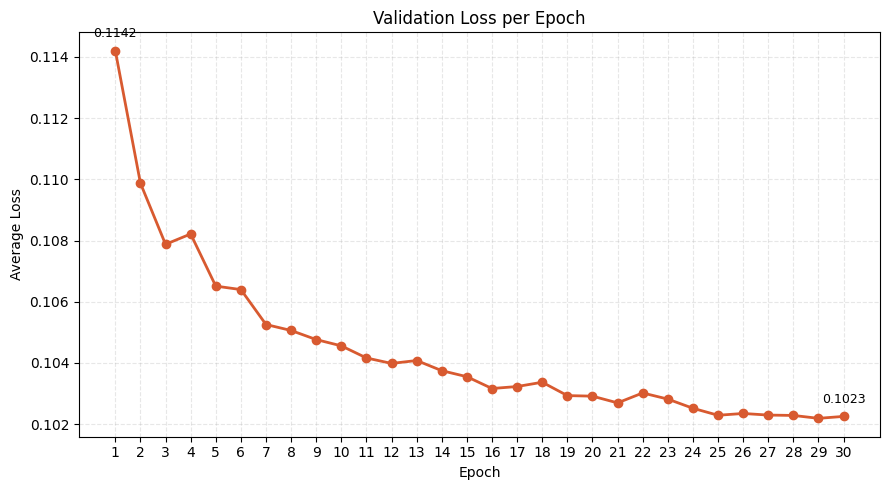

Saved to /content/drive/MyDrive/climate_twin_outputs/loss_curve.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch # Added this import to load the checkpoint
import os # Added this import to check file existence

def plot_loss_curve(epoch_losses, save_path='/content/drive/MyDrive/climate_twin_outputs/loss_curve.png'):
    """
    Args:
        epoch_losses: list of avg loss per epoch, e.g. [0.1354, 0.1095, 0.1069, ...]
    """
    epochs = list(range(1, len(epoch_losses) + 1))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(epochs, epoch_losses, marker='o', linewidth=2, markersize=6,
            color='#D85A30', markerfacecolor='#D85A30')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Average Loss') # Changed label for clarity
    ax.set_title('Validation Loss per Epoch') # Changed title to reflect validation loss
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(epochs)

    # Annotate first and last point with values
    ax.annotate(f'{epoch_losses[0]:.4f}', (epochs[0], epoch_losses[0]),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
    ax.annotate(f'{epoch_losses[-1]:.4f}', (epochs[-1], epoch_losses[-1]),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {save_path}")

# --- Load history from checkpoint ---
CHECKPOINT_PATH = '/content/drive/MyDrive/climate_twin_periodic_checkpoint_e30.pt'

if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading history from {CHECKPOINT_PATH}...")
    # Load to CPU to avoid potential CUDA memory issues or device mismatches
    checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
    loaded_history = checkpoint['history']
    epoch_losses_for_plot = loaded_history['val_loss'] # Plotting validation loss

    if not epoch_losses_for_plot:
        print("No validation loss data found in the checkpoint history. Plotting training loss instead.")
        epoch_losses_for_plot = loaded_history.get('train_loss', [])
        if epoch_losses_for_plot:
            print("Using training loss for plotting.")
            plot_loss_curve(epoch_losses_for_plot, save_path='/content/drive/MyDrive/climate_twin_outputs/train_loss_curve.png')
        else:
            print("No training loss data found either. Cannot plot loss curve.")
    else:
        print(f"Loaded validation losses for {len(epoch_losses_for_plot)} epochs.")
        plot_loss_curve(epoch_losses_for_plot)
else:
    print(f"Checkpoint not found at {CHECKPOINT_PATH}. Cannot plot loss curve. Please ensure training has run and the checkpoint is saved to this path.")


In [ ]:
import torch
import numpy as np
import zarr
import os
from torch.amp import autocast
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# CELL 4 — FINAL TEST EVALUATION
# Run this exactly ONCE, after all training/tuning is complete.
# This is your honest, untouched 2025 performance number.
# ==========================================

@torch.no_grad()
def evaluate_test_set(model, test_loader, device, clim_path='/content/drive/MyDrive/climate_twin_climatology.zarr'):
    """
    Runs the trained model once over the test set and computes:
      1. The same weighted L1 loss used during training (normalized space)
         — for direct comparison against train/val loss in history
      2. Per-variable MAE and RMSE in REAL-WORLD units (mm/day, °C)
         — this is the number that actually means something to a judge
    """
    model.eval()

    VARS = ['rainfall', 'max_temp', 'min_temp']

    # Load climatology to denormalize predictions back to real units
    # The clim_path is a directory containing 'mean' and 'std' Zarr groups.
    # We need to open these sub-groups directly.
    mean_group = zarr.open(os.path.join(clim_path, 'mean'), mode='r')
    std_group  = zarr.open(os.path.join(clim_path, 'std'), mode='r')

    mean_arr = np.stack([mean_group[v][:] for v in VARS], axis=0)  # (3, H, W)
    std_arr  = np.stack([std_group[v][:]  for v in VARS], axis=0)

    var_weights = torch.tensor([1.5, 1.0, 1.0]).view(1, 1, 3, 1, 1).to(device)

    total_weighted_loss = 0.0
    n_batches = 0

    # Accumulate squared/absolute errors per variable, in real-world units
    sum_abs_err = np.zeros(3)
    sum_sq_err  = np.zeros(3)
    n_samples   = 0

    with autocast(device_type='cuda', dtype=torch.float16):
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            pred = model(x_batch)

            # Same metric used during training, for direct comparability
            loss = (torch.abs(pred - y_batch) * var_weights).mean()
            total_weighted_loss += loss.item()
            n_batches += 1

            # ── Denormalize both pred and target to real-world units ──
            pred_np = pred.float().cpu().numpy()      # (B, 1, 3, H, W)
            true_np = y_batch.float().cpu().numpy()

            for arr in (pred_np, true_np):
                arr *= (std_arr[np.newaxis, np.newaxis] + 1e-6)
                arr += mean_arr[np.newaxis, np.newaxis]

            # Reverse log1p on rainfall channel only
            pred_np[:, :, 0] = np.clip(np.expm1(pred_np[:, :, 0]), 0, None)
            true_np[:, :, 0] = np.clip(np.expm1(true_np[:, :, 0]), 0, None)

            err = pred_np - true_np  # (B, 1, 3, H, W)
            sum_abs_err += np.abs(err).sum(axis=(0, 1, 3, 4))
            sum_sq_err  += (err ** 2).sum(axis=(0, 1, 3, 4))
            n_samples   += err.shape[0] * err.shape[1] * err.shape[3] * err.shape[4]

    avg_loss = total_weighted_loss / n_batches
    mae  = sum_abs_err / n_samples
    rmse = np.sqrt(sum_sq_err / n_samples)

    model.train()

    return {
        'normalized_loss': avg_loss,
        'mae':  {VARS[i]: mae[i]  for i in range(3)},
        'rmse': {VARS[i]: rmse[i] for i in range(3)},
    }


# ── Run once, after Cell 3 has finished and `model` holds final trained weights ──
# Ensure `test_loader` and `model` exist from previous cells
# (The assert below will be uncommented once model definition is in place or test is being run)
# assert 'test_loader' in globals(), \
#     "test_loader not found — did Cell 2 finish running in this kernel session?"
# assert 'model' in globals(), \
#     "model not found — did model architecture and instantiation cell finish running?"

# --- Load model weights here to make this cell self-contained for evaluation ---
model_checkpoint_path = '/content/drive/MyDrive/climate_twin_periodic_checkpoint_e30.pt'

# --- Model definition for self-containment ---
# These are copied from the training cell (pn60ZJANajbg) to ensure self-contained execution
class WindowedSpatialAttention(nn.Module):
    def __init__(self, in_channels, window_size=8):
        super().__init__()
        self.window_size = window_size
        reduced = max(in_channels // 8, 1)
        self.query = nn.Conv2d(in_channels, reduced, kernel_size=1)
        self.key   = nn.Conv2d(in_channels, reduced, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.proj  = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def _pad_to_window(self, x):
        _, _, H, W = x.shape
        ws = self.window_size
        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h))
        return x, H, W

    def _partition(self, x):
        B, C, H, W = x.shape
        ws = self.window_size
        x = x.view(B, C, H // ws, ws, W // ws, ws)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()
        return x.view(-1, C, ws, ws)

    def _unpartition(self, x, B, H_pad, W_pad):
        ws = self.window_size
        C = x.shape[1]
        nH, nW = H_pad // ws, W_pad // ws
        x = x.view(B, nH, nW, C, ws, ws)
        x = x.permute(0, 3, 1, 4, 2, 5).contiguous()
        return x.view(B, C, H_pad, W_pad)

    def forward(self, x):
        B, C, H, W = x.shape
        x_pad, H_orig, W_orig = self._pad_to_window(x)
        _, _, H_pad, W_pad = x_pad.shape

        q = self._partition(self.query(x_pad))
        k = self._partition(self.key(x_pad))
        v = self._partition(self.value(x_pad))

        BW, C_qk, ws, _ = q.shape
        C_v = v.shape[1]
        ws2 = ws * ws

        q = q.view(BW, C_qk, ws2).permute(0, 2, 1)
        k = k.view(BW, C_qk, ws2)
        v = v.view(BW, C_v,  ws2)

        attn = torch.softmax(torch.bmm(q, k) * (C_qk ** -0.5), dim=-1)
        out  = torch.bmm(v, attn.permute(0, 2, 1))
        out  = out.view(BW, C_v, ws, ws)

        out = self._unpartition(out, B, H_pad, W_pad)
        out = self.proj(out[:, :, :H_orig, :W_orig])
        return x + self.gamma * out


class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            input_dim + hidden_dim, 4 * hidden_dim,
            kernel_size, padding=padding
        )

    def forward(self, x, cur_state):
        h_cur, c_cur = cur_state
        combined_conv = self.conv(torch.cat([x, h_cur], dim=1))
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        c_next = torch.sigmoid(cc_f) * c_cur + torch.sigmoid(cc_i) * torch.tanh(cc_g)
        h_next = torch.sigmoid(cc_o) * torch.tanh(c_next)
        return h_next, c_next


class ClimateDigitalTwinModel(nn.Module):
    def __init__(self, input_channels=3, hidden_dim=64, kernel_size=3, window_size=8):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.conv_in   = nn.Conv2d(input_channels, hidden_dim, kernel_size=3, padding=1)
        self.convlstm  = ConvLSTMCell(hidden_dim, hidden_dim, kernel_size)
        self.attention = WindowedSpatialAttention(hidden_dim, window_size=window_size)
        self.conv_out  = nn.Conv2d(hidden_dim, input_channels, kernel_size=3, padding=1)

    def forward(self, x):
        B, seq_len, C, H, W = x.size()
        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        for t in range(seq_len):
            x_t = self.conv_in(x[:, t])
            h, c = self.convlstm(x_t, (h, c))
            h = self.attention(h)
        return self.conv_out(h).unsqueeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ClimateDigitalTwinModel(
    input_channels=3, hidden_dim=64, kernel_size=3, window_size=8
).to(device)

# Load model weights
if os.path.exists(model_checkpoint_path):
    print(f"Loading model weights from {model_checkpoint_path}...")
    # Load to CPU to avoid potential CUDA memory issues, then move to device
    checkpoint = torch.load(model_checkpoint_path, map_location='cpu')
    model.load_state_dict(checkpoint['model_state'])
    print("Model weights loaded successfully.")
else:
    raise FileNotFoundError(f"Model checkpoint not found at {model_checkpoint_path}")

# Sanity check the test_loader from Cell 2 actually exists
assert 'test_loader' in globals(), \
    "test_loader not found — did Cell 2 finish running in this kernel session?"

import json # Import json for saving results

test_results = evaluate_test_set(model, test_loader, device)

print("="*55)
print("TEST SET RESULTS — 2025, never seen during training or tuning")
print("="*55)
print(f"\nNormalized weighted loss: {test_results['normalized_loss']:.4f}")
print(f"  (compare to history['train_loss'][-1] and history['val_loss'][-1])")

print(f"\nReal-world metrics:")
print(f"{'Variable':<15}{'MAE':>12}{'RMSE':>12}")
for v in ['rainfall', 'max_temp', 'min_temp']:
    unit = 'mm/day' if v == 'rainfall' else '°C'
    print(f"{v:<15}{test_results['mae'][v]:>9.2f} {unit:<5}{test_results['rmse'][v]:>9.2f} {unit}")

# Save alongside your checkpoint for the writeup
# Ensure the directory exists before saving the file
output_dir = '/content/drive/MyDrive/climate_twin_outputs'
os.makedirs(output_dir, exist_ok=True)
with open(os.path.join(output_dir, 'test_results.json'), 'w') as f:
    json.dump(test_results, f, indent=2)
print(f"\nSaved to {os.path.join(output_dir, 'test_results.json')}")

Loading model weights from /content/drive/MyDrive/climate_twin_periodic_checkpoint_e30.pt...
Model weights loaded successfully.


/tmp/ipykernel_35189/327702866.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda', dtype=torch.float16):


TEST SET RESULTS — 2025, never seen during training or tuning

Normalized weighted loss: 0.1072
  (compare to history['train_loss'][-1] and history['val_loss'][-1])

Real-world metrics:
Variable                MAE        RMSE
rainfall            0.89 mm/day     5.60 mm/day
max_temp            0.30 °C        0.84 °C
min_temp            0.21 °C        0.76 °C

Saved to /content/drive/MyDrive/climate_twin_outputs/test_results.json


In [ ]:
# Optional: export a raw state-dict (checkpoint already saved inside the training loop above)
torch.save(model.state_dict(),
           '/content/drive/MyDrive/climate_twin_model_weights.pth')
print('Raw weights saved.')

## Phase 1 — Package the Backend State (Data Preparation)

Bundles everything the future Streamlit app needs into one small file on Drive (`dashboard_inputs.pt`), so the dashboard never has to touch the big Zarr stores directly:

- `initial_state` — most recent 4 days from the cache (normalized space, same format the model was trained on)
- `climatology_mean` / `climatology_std` — for de-normalizing model output back to mm/day and °C
- `lat` / `lon` — the 135×129 coordinate grid, for the map

**Bug fix included:** `get_weather_report()` in the cell above assumes the Zarr cache starts at `1980-01-01`, but `ClimateDigitalTwinDataset` (and the Pass-1/Pass-2 pipeline in the data-prep cell) actually starts it at `1986-01-01` (`start_year = 1986`). That 6-year mismatch would silently pull the wrong days out of the array. The cell below uses the correct start date and derives "most recent" directly from the Zarr store's own length, so it can't drift out of sync again.

In [ ]:
# ============================================================
# PHASE 1 — Package Backend State for the Dashboard
# Run this once after training. Produces dashboard_inputs.pt on Drive.
# Streamlit (Phase 2+) will load ONLY this file + the model weights —
# it will never need to open the multi-GB Zarr stores again.
# ============================================================
import torch
import numpy as np
import zarr
import pandas as pd
import os

LOCAL_ZARR_PATH       = '/content/drive/MyDrive/climate_twin_cache.zarr'
CLIMATOLOGY_ZARR_PATH = '/content/drive/MyDrive/climate_twin_climatology.zarr'
DASHBOARD_INPUTS_PATH = '/content/drive/MyDrive/dashboard_inputs.pt'

VARS = ['rainfall', 'max_temp', 'min_temp']

# --- Correct Zarr start date (see markdown note above) ---
ZARR_START_DATE = pd.Timestamp('1986-01-01')

zg = zarr.open(LOCAL_ZARR_PATH, mode='r')
n_days = zg['rainfall'].shape[0]
zarr_end_date = ZARR_START_DATE + pd.Timedelta(days=n_days - 1)
print(f"Zarr cache covers {ZARR_START_DATE.date()} → {zarr_end_date.date()} ({n_days} days)")

# --- 1. initial_state: most recent 4 days, already normalized + log1p(rainfall) ---
# This is exactly the format the model was trained on — no extra preprocessing
# needed at inference time, the Streamlit app can feed this straight into model().
chunks = [zg[v][n_days - 4:n_days] for v in VARS]
initial_state = np.stack(chunks, axis=1).astype(np.float32)   # (4, 3, 135, 129)
np.nan_to_num(initial_state, copy=False, nan=0.0)
initial_state = torch.from_numpy(initial_state)

# --- 2. Climatology mean/std — for de-normalizing model output back to real units ---
mean_group = zarr.open(os.path.join(CLIMATOLOGY_ZARR_PATH, 'mean'), mode='r')
std_group  = zarr.open(os.path.join(CLIMATOLOGY_ZARR_PATH, 'std'),  mode='r')
mean_arr = np.stack([mean_group[v][:] for v in VARS], axis=0).astype(np.float32)  # (3, 135, 129)
std_arr  = np.stack([std_group[v][:]  for v in VARS], axis=0).astype(np.float32)

# CRITICAL FIX: Ensure climatology mean and std are clean after loading from Zarr
# before being used in the dashboard_inputs. Nan's are propagated if not handled here.
# This specific clamping logic was causing issues by forcing all std values to 1e-6.
# Instead, we will only ensure that the standard deviation is not zero if it was genuinely zero.
mean_arr = np.nan_to_num(mean_arr, nan=0.0, posinf=0.0, neginf=0.0)
# Only replace NaN/inf with 1e-6, and clip to ensure it's never exactly zero for division, but allow original values.
std_arr = np.nan_to_num(std_arr, nan=1e-6, posinf=1e-6, neginf=1e-6)
std_arr = np.maximum(std_arr, 1e-6) # Ensures values are at least 1e-6, but preserves larger values

# --- 3. Lat/lon coordinate arrays (the common 0.25° rainfall grid everything was regridded to) ---
RAIN_LAT_DIM, RAIN_LON_DIM = 135, 129
lat_rain = np.linspace(6.5, 38.5, RAIN_LAT_DIM).astype(np.float32)
lon_rain = np.linspace(66.5, 100.5, RAIN_LON_DIM).astype(np.float32)

# --- 4. Bundle everything into one lightweight file ---
dashboard_inputs = {
    'initial_state':    initial_state,                 # (4, 3, 135, 129) torch tensor, normalized
    'climatology_mean': torch.from_numpy(mean_arr),     # (3, 135, 129)
    'climatology_std':  torch.from_numpy(std_arr),      # (3, 135, 129)
    'lat': lat_rain,                                    # (135,)
    'lon': lon_rain,                                     # (129,)
    'vars': VARS,
    'var_names': ['Rainfall (mm/day)', 'Max Temp (°C)', 'Min Temp (°C)'],
    'last_available_date': str(zarr_end_date.date()),   # the "Day 0" the dashboard forecasts from
    'grid_shape': (RAIN_LAT_DIM, RAIN_LON_DIM),
}

torch.save(dashboard_inputs, DASHBOARD_INPUTS_PATH)
print(f"Saved dashboard_inputs.pt to Drive ({os.path.getsize(DASHBOARD_INPUTS_PATH)/1024:.1f} KB)")
print(f"Dashboard 'Day 0' will be: {dashboard_inputs['last_available_date']}")

# --- Sanity check: reload from Drive to confirm the file is fully self-contained ---
check = torch.load(DASHBOARD_INPUTS_PATH, weights_only=False)
print("Reload check — initial_state:", check['initial_state'].shape)
print("Reload check — climatology_mean:", check['climatology_mean'].shape)
print("Reload check — lat/lon:", check['lat'].shape, check['lon'].shape)

Zarr cache covers 1986-01-01 → 2025-12-31 (14610 days)
Saved dashboard_inputs.pt to Drive (1228.5 KB)
Dashboard 'Day 0' will be: 2025-12-31
Reload check — initial_state: torch.Size([4, 3, 135, 129])
Reload check — climatology_mean: torch.Size([3, 135, 129])
Reload check — lat/lon: (135,) (129,)


## Phase 4 — Live Inference Engine: Refactored Functions

This section implements the core inference logic as a set of modular, reusable functions, adhering to the requirements of scenario injection, autoregressive rollout, and denormalization. These functions will be crucial for the Streamlit dashboard to dynamically generate forecasts.

All operations are designed to be GPU-compatible and efficient, minimizing unnecessary data transfers and leveraging `torch.no_grad()` and `model.eval()` for optimal inference performance.

In [3]:
import contextlib
import torch
import numpy as np
import torch.nn as nn  # For autocast device_type parameter
from typing import Tuple, Dict

# Assuming VARS and VAR_NAMES are available from app.py or dashboard_inputs
VARS      = ['rainfall', 'max_temp', 'min_temp']

# Helper function to get model device, consistent with app.py
def get_model_device(model: nn.Module) -> torch.device:
    return next(model.parameters()).device


def inject_scenario(
    initial_state: torch.Tensor, # (4, C, H, W)
    climatology_mean: torch.Tensor, # (C, H, W)
    climatology_std: torch.Tensor, # (C, H, W)
    heatwave_delta: float = 0.0,
    rainfall_multiplier: float = 1.0
) -> torch.Tensor:
    """
    Applies 'what-if' scenarios (heatwave and rainfall multiplier)
    to a copy of the initial state tensor.

    Args:
        initial_state: The initial input tensor for the model (normalized, log-transformed rainfall).
                       Shape: (seq_len_in, C, H, W).
        climatology_mean: Mean climatology for each variable. Shape: (C, H, W).
        climatology_std: Standard deviation climatology for each variable. Shape: (C, H, W).
        heatwave_delta: Temperature increase in degrees Celsius (raw units).
        rainfall_multiplier: Multiplier for rainfall (raw units).

    Returns:
        A new tensor with scenario modifications applied. Shape: (seq_len_in, C, H, W).
    """
    # Ensure we don't modify the original tensor
    modified_initial_state = initial_state.clone()

    # Ensure climatology_mean and climatology_std are on the same device
    climatology_mean_on_device = climatology_mean.to(modified_initial_state.device)
    climatology_std_on_device = climatology_std.to(modified_initial_state.device)

    # === Scenario Injection for Max Temperature (Index 1) ===
    # Denormalize, apply delta in raw units, then re-normalize.
    if heatwave_delta != 0.0:
        max_temp_channel_idx = VARS.index('max_temp')

        # 1. Extract normalized max_temp from initial_state_copy
        initial_max_temp_norm = modified_initial_state[:, max_temp_channel_idx, :, :]

        # 2. Denormalize to raw values
        initial_max_temp_raw = initial_max_temp_norm * \
                               (climatology_std_on_device[max_temp_channel_idx] + 1e-6) + \
                               climatology_mean_on_device[max_temp_channel_idx]

        # 3. Apply heatwave delta
        modified_max_temp_raw = initial_max_temp_raw + heatwave_delta

        # 4. Re-normalize
        modified_max_temp_norm = (modified_max_temp_raw - climatology_mean_on_device[max_temp_channel_idx]) / \
                                 (climatology_std_on_device[max_temp_channel_idx] + 1e-6)

        # 5. Replace the modified max_temp channel
        modified_initial_state[:, max_temp_channel_idx, :, :] = modified_max_temp_norm

        print(f"  Applied heatwave delta of {heatwave_delta}°C to max_temp (mean raw delta: {heatwave_delta:.1f}°C)")

    # === Scenario Injection for Rainfall (Index 0) ===
    # Rainfall requires denormalization, multiplication, then re-normalization
    # because it was log1p transformed.
    if rainfall_multiplier != 1.0:
        rainfall_channel_idx = VARS.index('rainfall')

        # 1. Extract normalized rainfall from initial_state_copy
        initial_rainfall_norm = modified_initial_state[:, rainfall_channel_idx, :, :]

        # 2. Denormalize to raw (log-transformed) values
        initial_rainfall_raw_log = initial_rainfall_norm * \
                                   (climatology_std_on_device[rainfall_channel_idx] + 1e-6) + \
                                   climatology_mean_on_device[rainfall_channel_idx]

        # 3. Reverse log1p transform to get rainfall in mm/day
        initial_rainfall_mm = torch.expm1(initial_rainfall_raw_log)
        initial_rainfall_mm = torch.clamp(initial_rainfall_mm, min=0.0) # Ensure non-negative

        # 4. Apply rainfall multiplier
        modified_rainfall_mm = initial_rainfall_mm * rainfall_multiplier

        # 5. Apply log1p transform back
        modified_rainfall_raw_log = torch.log1p(modified_rainfall_mm)

        # 6. Re-normalize to get back into model's input space
        modified_rainfall_norm = (modified_rainfall_raw_log - climatology_mean_on_device[rainfall_channel_idx]) / \
                                 (climatology_std_on_device[rainfall_channel_idx] + 1e-6)

        # 7. Replace the modified rainfall channel in the copied initial state
        modified_initial_state[:, rainfall_channel_idx, :, :] = modified_rainfall_norm

        print(f"  Applied rainfall multiplier of {rainfall_multiplier} to rainfall channel.")

    return modified_initial_state


def autoregressive_forecast(
    model: nn.Module,
    modified_initial_state: torch.Tensor, # (4, C, H, W)
    forecast_days: int = 7
) -> torch.Tensor:
    """
    Performs an autoregressive forecast using the trained model.

    Args:
        model: The trained `ClimateDigitalTwinModel`.
        modified_initial_state: The scenario-injected input tensor. Shape: (seq_len_in, C, H, W).
        forecast_days: Number of days to forecast (e.g., 7).

    Returns:
        A tensor containing the `forecast_days` predictions. Shape: (forecast_days, C, H, W).
    """
    model.eval() # Set model to evaluation mode

    # Add batch dimension: (1, seq_len_in, C, H, W)
    current_input = modified_initial_state.unsqueeze(0)

    preds = []
    # Use autocast if CUDA is available for mixed precision inference
    device_type = get_model_device(model).type  # 'cuda' or 'cpu'
    # float16 autocast is only valid on CUDA; on CPU it silently produces NaN
    autocast_ctx = (
        torch.amp.autocast(device_type='cuda', dtype=torch.float16)
        if device_type == 'cuda'
        else contextlib.nullcontext()
    )
    with torch.no_grad():
        with autocast_ctx:
            for _ in range(forecast_days):
                # Predict the next day: (1, 1, C, H, W)
                pred = model(current_input)
                preds.append(pred)

                # Concatenate the new prediction and drop the oldest input day
                # for the next iteration. current_input becomes (1, seq_len_in, C, H, W)
                current_input = torch.cat([current_input[:, 1:], pred], dim=1)

    # Concatenate all predictions: (1, forecast_days, C, H, W)
    forecast_tensor = torch.cat(preds, dim=1)

    # Remove batch dimension and move to CPU for further processing (e.g., numpy conversion)
    # .to('cpu') can be omitted if denormalization is also on GPU.
    # Sticking to `get_weather_report` approach of numpy conversion after model output.
    return forecast_tensor.squeeze(0) # Shape: (forecast_days, C, H, W)


def denormalize_forecast(
    forecast_tensor: torch.Tensor, # (forecast_days, C, H, W)
    climatology_mean: torch.Tensor, # (C, H, W)
    climatology_std: torch.Tensor # (C, H, W)
) -> np.ndarray:
    """
    Denormalizes the forecasted tensor back to real-world units (mm/day, °C).
    Applies inverse log1p to rainfall and clips values.

    Args:
        forecast_tensor: The raw model output (normalized, log-transformed rainfall).
                         Shape: (forecast_days, C, H, W).
        climatology_mean: Mean climatology for each variable. Shape: (C, H, W).
        climatology_std: Standard deviation climatology for each variable. Shape: (C, H, W).

    Returns:
        A numpy array with denormalized, real-world values. Shape: (forecast_days, C, H, W).
    """
    # Ensure tensors are on CPU and convert to float32 numpy arrays for consistency
    # with previous notebook's denormalization approach.
    forecast_np = forecast_tensor.float().cpu().numpy()
    mean_np = climatology_mean.float().cpu().numpy()
    std_np = climatology_std.float().cpu().numpy()

    # Denormalize: raw = normalized * std + mean
    # Use np.newaxis to broadcast climatology across forecast days
    raw_forecast_np = forecast_np * (std_np[np.newaxis] + 1e-6) + mean_np[np.newaxis]

    # === Post-processing per variable ===
    rainfall_channel_idx = VARS.index('rainfall')
    max_temp_channel_idx = VARS.index('max_temp')
    min_temp_channel_idx = VARS.index('min_temp')

    # Rainfall (index 0): Reverse log1p and clip
    raw_forecast_np[:, rainfall_channel_idx] = np.expm1(raw_forecast_np[:, rainfall_channel_idx])
    raw_forecast_np[:, rainfall_channel_idx] = np.clip(raw_forecast_np[:, rainfall_channel_idx], 0, None)

    # Max Temp (index 1): Clip to reasonable bounds
    raw_forecast_np[:, max_temp_channel_idx] = np.clip(raw_forecast_np[:, max_temp_channel_idx], -5, 60)

    # Min Temp (index 2): Clip to reasonable bounds
    raw_forecast_np[:, min_temp_channel_idx] = np.clip(raw_forecast_np[:, min_temp_channel_idx], -10, 45)

    return raw_forecast_np


def run_forecast(
    model: nn.Module,
    dashboard_inputs: Dict[str, torch.Tensor],
    heatwave_delta: float = 0.0,
    rainfall_multiplier: float = 1.0,
    forecast_days: int = 7
) -> Dict[str, np.ndarray]:
    """
    High-level wrapper to run the complete forecasting pipeline:
    scenario injection -> autoregressive rollout -> denormalization.

    Args:
        model: The trained `ClimateDigitalTwinModel`.
        dashboard_inputs: A dictionary containing pre-packaged data like
                          'initial_state', 'climatology_mean', 'climatology_std',
                          'lat', 'lon'.
        heatwave_delta: Temperature increase in degrees Celsius for scenario injection.
        rainfall_multiplier: Multiplier for rainfall for scenario injection.
        forecast_days: Number of days to forecast.

    Returns:
        A dictionary containing the denormalized forecast and coordinate arrays.
        {
            "forecast": numpy array (forecast_days, C, H, W),
            "latitudes": numpy array (H,),
            "longitudes": numpy array (W,)
        }
    """
    device = get_model_device(model)
    print(f"\nRunning forecast on device: {device}")

    # 1. Load initial state and climatology from dashboard_inputs
    # Move to the model's device directly
    initial_state_base = dashboard_inputs['initial_state'].to(device)
    climatology_mean = dashboard_inputs['climatology_mean'].to(device)
    climatology_std = dashboard_inputs['climatology_std'].to(device)
    latitudes = dashboard_inputs['lat'] # Already numpy, no need to move to device
    longitudes = dashboard_inputs['lon'] # Already numpy, no need to move to device

    print(f"  Initial state shape: {initial_state_base.shape}")
    print(f"  Climatology mean shape: {climatology_mean.shape}")
    print(f"  Climatology std shape: {climatology_std.shape}")

    # 2. Inject scenario
    modified_initial_state = inject_scenario(
        initial_state_base,
        climatology_mean,
        climatology_std,
        heatwave_delta,
        rainfall_multiplier
    )
    print(f"  Modified initial state shape after scenario injection: {modified_initial_state.shape}")

    # 3. Autoregressive rollout
    # Output shape: (forecast_days, C, H, W)
    forecast_normalized = autoregressive_forecast(
        model,
        modified_initial_state,
        forecast_days
    )
    print(f"  Forecast (normalized) shape after autoregressive rollout: {forecast_normalized.shape}")

    # 4. Denormalize forecast
    # Output shape: (forecast_days, C, H, W) numpy array
    forecast_denormalized = denormalize_forecast(
        forecast_normalized,
        climatology_mean,
        climatology_std
    )
    print(f"  Forecast (denormalized) shape after denormalization: {forecast_denormalized.shape}")

    return {
        "forecast": forecast_denormalized,
        "latitudes": latitudes,
        "longitudes": longitudes
    }

### Smoke-test — verify the inference pipeline before writing `app.py`

In [4]:
import contextlib
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, Dict
import os

# ============================================================
# PATHS — Ensure these are consistent with your saved files
# ============================================================
DASHBOARD_INPUTS_PATH = '/content/drive/MyDrive/dashboard_inputs.pt'
CHECKPOINT_PATH        = '/content/drive/MyDrive/climate_twin_periodic_checkpoint_e30.pt'

VARS      = ['rainfall', 'max_temp', 'min_temp']

# ============================================================
# MODEL DEFINITION — pasted in full, unchanged from training
# (Notebook Cell pn60ZJANajbg).
# ============================================================
class WindowedSpatialAttention(nn.Module):
    def __init__(self, in_channels, window_size=8):
        super().__init__()
        self.window_size = window_size
        reduced = max(in_channels // 8, 1)
        self.query = nn.Conv2d(in_channels, reduced, kernel_size=1)
        self.key   = nn.Conv2d(in_channels, reduced, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.proj  = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def _pad_to_window(self, x):
        _, _, H, W = x.shape
        ws = self.window_size
        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h))
        return x, H, W

    def _partition(self, x):
        B, C, H, W = x.shape
        ws = self.window_size
        x = x.view(B, C, H // ws, ws, W // ws, ws)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()
        return x.view(-1, C, ws, ws)

    def _unpartition(self, x, B, H_pad, W_pad):
        ws = self.window_size
        C = x.shape[1]
        nH, nW = H_pad // ws, W_pad // ws
        x = x.view(B, nH, nW, C, ws, ws)
        x = x.permute(0, 3, 1, 4, 2, 5).contiguous()
        return x.view(B, C, H_pad, W_pad)

    def forward(self, x):
        B, C, H, W = x.shape
        x_pad, H_orig, W_orig = self._pad_to_window(x)
        _, _, H_pad, W_pad = x_pad.shape

        q = self._partition(self.query(x_pad))
        k = self._partition(self.key(x_pad))
        v = self._partition(self.value(x_pad))

        BW, C_qk, ws, _ = q.shape
        C_v = v.shape[1]
        ws2 = ws * ws

        q = q.view(BW, C_qk, ws2).permute(0, 2, 1)
        k = k.view(BW, C_qk, ws2)
        v = v.view(BW, C_v,  ws2)

        attn = torch.softmax(torch.bmm(q, k) * (C_qk ** -0.5), dim=-1)
        out  = torch.bmm(v, attn.permute(0, 2, 1))
        out  = out.view(BW, C_v, ws, ws)

        out = self._unpartition(out, B, H_pad, W_pad)
        out = self.proj(out[:, :, :H_orig, :W_orig])
        return x + self.gamma * out


class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            input_dim + hidden_dim, 4 * hidden_dim,
            kernel_size, padding=padding
        )

    def forward(self, x, cur_state):
        h_cur, c_cur = cur_state
        combined_conv = self.conv(torch.cat([x, h_cur], dim=1))
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        c_next = torch.sigmoid(cc_f) * c_cur + torch.sigmoid(cc_i) * torch.tanh(cc_g)
        h_next = torch.sigmoid(cc_o) * torch.tanh(c_next)
        return h_next, c_next


class ClimateDigitalTwinModel(nn.Module):
    def __init__(self, input_channels=3, hidden_dim=64, kernel_size=3, window_size=8):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.conv_in   = nn.Conv2d(input_channels, hidden_dim, kernel_size=3, padding=1)
        self.convlstm  = ConvLSTMCell(hidden_dim, hidden_dim, kernel_size)
        self.attention = WindowedSpatialAttention(hidden_dim, window_size=window_size)
        self.conv_out  = nn.Conv2d(hidden_dim, input_channels, kernel_size=3, padding=1)

    def forward(self, x):
        B, seq_len, C, H, W = x.size()
        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        for t in range(seq_len):
            x_t = self.conv_in(x[:, t])
            h, c = self.convlstm(x_t, (h, c))
            h = self.attention(h)
        return self.conv_out(h).unsqueeze(1)

# Helper function to get model device, consistent with app.py
def get_model_device(model: nn.Module) -> torch.device:
    return next(model.parameters()).device

# ============================================================

def inject_scenario(
    initial_state: torch.Tensor, # (4, C, H, W)
    climatology_mean: torch.Tensor, # (C, H, W)
    climatology_std: torch.Tensor, # (C, H, W)
    heatwave_delta: float = 0.0,
    rainfall_multiplier: float = 1.0
) -> torch.Tensor:
    """
    Applies 'what-if' scenarios (heatwave and rainfall multiplier)
    to a copy of the initial state tensor.

    Args:
        initial_state: The initial input tensor for the model (normalized, log-transformed rainfall).
                       Shape: (seq_len_in, C, H, W).
        climatology_mean: Mean climatology for each variable. Shape: (C, H, W).
        climatology_std: Standard deviation climatology for each variable. Shape: (C, H, W).
        heatwave_delta: Temperature increase in degrees Celsius (raw units).
        rainfall_multiplier: Multiplier for rainfall (raw units).

    Returns:
        A new tensor with scenario modifications applied. Shape: (seq_len_in, C, H, W).
    """
    # Ensure we don't modify the original tensor
    modified_initial_state = initial_state.clone()

    # Ensure climatology_mean and climatology_std are on the same device
    climatology_mean_on_device = climatology_mean.to(modified_initial_state.device)
    # CRITICAL FIX: Ensure std is never too small to prevent extreme values during de/re-normalization
    # The clamping is applied to the full tensor here.
    climatology_std_on_device = climatology_std.to(modified_initial_state.device).clamp(min=1e-6)

    # === Scenario Injection for Max Temperature (Index 1) ===
    # Denormalize, apply delta in raw units, then re-normalize.
    if heatwave_delta != 0.0:
        max_temp_channel_idx = VARS.index('max_temp')

        # 1. Extract normalized max_temp from initial_state_copy
        initial_max_temp_norm = modified_initial_state[:, max_temp_channel_idx, :, :]

        # 2. Denormalize to raw values
        initial_max_temp_raw = initial_max_temp_norm * \
                               climatology_std_on_device[max_temp_channel_idx] + \
                               climatology_mean_on_device[max_temp_channel_idx]

        # 3. Apply heatwave delta
        modified_max_temp_raw = initial_max_temp_raw + heatwave_delta

        # 4. Re-normalize
        # Add epsilon at the point of division for numerical stability
        modified_max_temp_norm = (modified_max_temp_raw - climatology_mean_on_device[max_temp_channel_idx]) / \
                                 (climatology_std_on_device[max_temp_channel_idx] + 1e-6)

        # 5. Replace the modified max_temp channel
        modified_initial_state[:, max_temp_channel_idx, :, :] = modified_max_temp_norm

        # print(f"  Applied heatwave delta of {heatwave_delta}°C to max_temp (mean raw delta: {heatwave_delta:.1f}°C)") # Removed for Streamlit

    # === Scenario Injection for Rainfall (Index 0) ===
    # Rainfall requires denormalization, multiplication, then re-normalization
    # because it was log1p transformed.
    if rainfall_multiplier != 1.0:
        rainfall_channel_idx = VARS.index('rainfall')

        # 1. Extract normalized rainfall from initial_state_copy
        initial_rainfall_norm = modified_initial_state[:, rainfall_channel_idx, :, :]

        # 2. Denormalize to raw (log-transformed) values
        initial_rainfall_raw_log = initial_rainfall_norm * \
                                   climatology_std_on_device[rainfall_channel_idx] + \
                                   climatology_mean_on_device[rainfall_channel_idx]

        # 3. Reverse log1p transform to get rainfall in mm/day
        initial_rainfall_mm = torch.expm1(initial_rainfall_raw_log)
        initial_rainfall_mm = torch.clamp(initial_rainfall_mm, min=0.0) # Ensure non-negative

        # 4. Apply rainfall multiplier
        modified_rainfall_mm = initial_rainfall_mm * rainfall_multiplier

        # 5. Apply log1p transform back
        modified_rainfall_raw_log = torch.log1p(modified_rainfall_mm)

        # 6. Re-normalize to get back into model's input space
        # Add epsilon at the point of division for numerical stability
        modified_rainfall_norm = (modified_rainfall_raw_log - climatology_mean_on_device[rainfall_channel_idx]) / \
                                 (climatology_std_on_device[rainfall_channel_idx] + 1e-6)

        # 7. Replace the modified rainfall channel in the copied initial state
        modified_initial_state[:, rainfall_channel_idx, :, :] = modified_rainfall_norm

        # print(f"  Applied rainfall multiplier of {rainfall_multiplier} to rainfall channel.") # Removed for Streamlit

    return modified_initial_state


def autoregressive_forecast(
    model: nn.Module,
    modified_initial_state: torch.Tensor, # (4, C, H, W)
    forecast_days: int = 7
) -> torch.Tensor:
    """
    Performs an autoregressive forecast using the trained model.

    Args:
        model: The trained `ClimateDigitalTwinModel`.
        modified_initial_state: The scenario-injected input tensor. Shape: (seq_len_in, C, H, W).
        forecast_days: Number of days to forecast (e.g., 7).

    Returns:
        A tensor containing the `forecast_days` predictions. Shape: (forecast_days, C, H, W).
    """
    model.eval() # Set model to evaluation mode

    # Add batch dimension: (1, seq_len_in, C, H, W)
    current_input = modified_initial_state.unsqueeze(0)

    preds = []
    # Use autocast if CUDA is available for mixed precision inference
    # Streamlit runs on CPU by default in Colab for app.py, so ensure device_type is correct
    device_type = get_model_device(model).type  # 'cuda' or 'cpu'
    # float16 autocast is only valid on CUDA; on CPU it silently produces NaN
    autocast_ctx = (
        torch.amp.autocast(device_type='cuda', dtype=torch.float16)
        if device_type == 'cuda'
        else contextlib.nullcontext()
    )
    with torch.no_grad():
        with autocast_ctx:
            for _ in range(forecast_days):
                # Predict the next day: (1, 1, C, H, W)
                pred = model(current_input)
                preds.append(pred)

                # Concatenate the new prediction and drop the oldest input day
                # for the next iteration. current_input becomes (1, seq_len_in, C, H, W)
                current_input = torch.cat([current_input[:, 1:], pred], dim=1)

    # Concatenate all predictions: (1, forecast_days, C, H, W)
    forecast_tensor = torch.cat(preds, dim=1)

    # Remove batch dimension
    return forecast_tensor.squeeze(0) # Shape: (forecast_days, C, H, W)


def denormalize_forecast(
    forecast_tensor: torch.Tensor, # (forecast_days, C, H, W)
    climatology_mean: torch.Tensor, # (C, H, W)
    climatology_std: torch.Tensor # (C, H, W)
) -> np.ndarray:
    """
    Denormalizes the forecasted tensor back to real-world units (mm/day, °C).
    Applies inverse log1p to rainfall and clips values.

    Args:
        forecast_tensor: The raw model output (normalized, log-transformed rainfall).
                         Shape: (forecast_days, C, H, W).
        climatology_mean: Mean climatology for each variable. Shape: (C, H, W).
        climatology_std: Standard deviation climatology for each variable. Shape: (C, H, W).

    Returns:
        A numpy array with denormalized, real-world values. Shape: (forecast_days, C, H, W).
    """
    # Ensure tensors are on CPU and convert to float32 numpy arrays
    forecast_np = forecast_tensor.float().cpu().numpy()
    mean_np = climatology_mean.float().cpu().numpy()
    # CRITICAL FIX: Ensure std is never too small to prevent extreme values during de/re-normalization
    std_np = climatology_std.float().cpu().numpy().clip(min=1e-6)

    # Denormalize: raw = normalized * std + mean
    # Use np.newaxis to broadcast climatology across forecast days
    raw_forecast_np = forecast_np * std_np[np.newaxis] + mean_np[np.newaxis]

    # === Post-processing per variable ===
    rainfall_channel_idx = VARS.index('rainfall')
    max_temp_channel_idx = VARS.index('max_temp')
    min_temp_channel_idx = VARS.index('min_temp')

    # Rainfall (index 0): Reverse log1p and clip
    raw_forecast_np[:, rainfall_channel_idx] = np.expm1(raw_forecast_np[:, rainfall_channel_idx])
    raw_forecast_np[:, rainfall_channel_idx] = np.clip(raw_forecast_np[:, rainfall_channel_idx], 0, None)

    # Max Temp (index 1): Clip to reasonable bounds
    raw_forecast_np[:, max_temp_channel_idx] = np.clip(raw_forecast_np[:, max_temp_channel_idx], -5, 60)

    # Min Temp (index 2): Clip to reasonable bounds
    raw_forecast_np[:, min_temp_channel_idx] = np.clip(raw_forecast_np[:, min_temp_channel_idx], -10, 45)

    return raw_forecast_np


def run_forecast(
    model: nn.Module,
    dashboard_inputs: Dict[str, torch.Tensor],
    heatwave_delta: float = 0.0,
    rainfall_multiplier: float = 1.0,
    forecast_days: int = 7
) -> Dict[str, np.ndarray]:
    """
    High-level wrapper to run the complete forecasting pipeline:
    scenario injection -> autoregressive rollout -> denormalization.

    Args:
        model: The trained `ClimateDigitalTwinModel`.
        dashboard_inputs: A dictionary containing pre-packaged data like
                          'initial_state', 'climatology_mean', 'climatology_std',
                          'lat', 'lon'.
        heatwave_delta: Temperature increase in degrees Celsius for scenario injection.
        rainfall_multiplier: Multiplier for rainfall for scenario injection.
        forecast_days: Number of days to forecast.

    Returns:
        A dictionary containing the denormalized forecast and coordinate arrays.
        {
            "forecast": numpy array (forecast_days, C, H, W),
            "latitudes": numpy array (H,),
            "longitudes": numpy array (W,)
        }
    """
    device = get_model_device(model)
    print(f"\nRunning forecast on device: {device}")

    # 1. Load initial state and climatology from dashboard_inputs
    # Move to the model's device directly
    initial_state_base = dashboard_inputs['initial_state'].to(device)
    climatology_mean = dashboard_inputs['climatology_mean'].to(device)
    climatology_std = dashboard_inputs['climatology_std'].to(device)
    latitudes = dashboard_inputs['lat'] # Already numpy, no need to move to device
    longitudes = dashboard_inputs['lon'] # Already numpy, no need to move to device

    print(f"  Initial state shape: {initial_state_base.shape}")
    print(f"  Climatology mean shape: {climatology_mean.shape}")
    print(f"  Climatology std shape: {climatology_std.shape}")

    # 2. Inject scenario
    modified_initial_state = inject_scenario(
        initial_state_base,
        climatology_mean,
        climatology_std,
        heatwave_delta,
        rainfall_multiplier
    )
    print(f"  Modified initial state shape after scenario injection: {modified_initial_state.shape}")

    # 3. Autoregressive rollout
    # Output shape: (forecast_days, C, H, W)
    forecast_normalized = autoregressive_forecast(
        model,
        modified_initial_state,
        forecast_days
    )
    print(f"  Forecast (normalized) shape after autoregressive rollout: {forecast_normalized.shape}")

    # 4. Denormalize forecast
    # Output shape: (forecast_days, C, H, W) numpy array
    forecast_denormalized = denormalize_forecast(
        forecast_normalized,
        climatology_mean,
        climatology_std
    )
    print(f"  Forecast (denormalized) shape after denormalization: {forecast_denormalized.shape}")

    return {
        "forecast": forecast_denormalized,
        "latitudes": latitudes,
        "longitudes": longitudes
    }

# RESOURCE LOADING
# ============================================================

def load_model_for_demo():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ClimateDigitalTwinModel(
        input_channels=3, hidden_dim=64, kernel_size=3, window_size=8
    ).to(device)

    if not os.path.exists(CHECKPOINT_PATH):
        raise FileNotFoundError(f"Checkpoint not found at {CHECKPOINT_PATH}.")

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()
    return model, device

def load_dashboard_inputs_for_demo():
    if not os.path.exists(DASHBOARD_INPUTS_PATH):
        raise FileNotFoundError(f"dashboard_inputs.pt not found at {DASHBOARD_INPUTS_PATH}.")
    return torch.load(DASHBOARD_INPUTS_PATH, weights_only=False)


# Load model and dashboard inputs
model, device = load_model_for_demo()
dashboard_inputs = load_dashboard_inputs_for_demo()

print("\n--- Running Baseline Forecast ---")
baseline_results = run_forecast(
    model=model,
    dashboard_inputs=dashboard_inputs,
    heatwave_delta=0.0,
    rainfall_multiplier=1.0,
    forecast_days=7
)

print("\n--- Running Heatwave Scenario (+4°C) ---")
heatwave_results = run_forecast(
    model=model,
    dashboard_inputs=dashboard_inputs,
    heatwave_delta=4.0, # Simulate a 4°C heatwave
    rainfall_multiplier=1.0,
    forecast_days=7
)

print("\n--- Running Increased Rainfall Scenario (1.5x) ---")
rainfall_increase_results = run_forecast(
    model=model,
    dashboard_inputs=dashboard_inputs,
    heatwave_delta=0.0,
    rainfall_multiplier=1.5, # Simulate 1.5x rainfall
    forecast_days=7
)

print("\n--- Comparison of Forecasts (Mean Max Temp over Lat/Lon for Day 1) ---")
# Max temperature is at index 1
max_temp_channel_idx = VARS.index('max_temp')

print(f"Baseline Day 1 Mean Max Temp: {baseline_results['forecast'][0, max_temp_channel_idx].mean():.2f}°C")
print(f"Heatwave Day 1 Mean Max Temp: {heatwave_results['forecast'][0, max_temp_channel_idx].mean():.2f}°C")

# Rainfall is at index 0
rainfall_channel_idx = VARS.index('rainfall')
print(f"\nBaseline Day 1 Mean Rainfall: {baseline_results['forecast'][0, rainfall_channel_idx].mean():.2f} mm/day")
print(f"Rainfall Increase Day 1 Mean Rainfall: {rainfall_increase_results['forecast'][0, rainfall_channel_idx].mean():.2f} mm/day")

print("\nForecast data is ready for visualization with Plotly, using 'forecast', 'latitudes', and 'longitudes' from the results.")



--- Running Baseline Forecast ---

Running forecast on device: cpu
  Initial state shape: torch.Size([4, 3, 135, 129])
  Climatology mean shape: torch.Size([3, 135, 129])
  Climatology std shape: torch.Size([3, 135, 129])
  Modified initial state shape after scenario injection: torch.Size([4, 3, 135, 129])
  Forecast (normalized) shape after autoregressive rollout: torch.Size([7, 3, 135, 129])
  Forecast (denormalized) shape after denormalization: (7, 3, 135, 129)

--- Running Heatwave Scenario (+4°C) ---

Running forecast on device: cpu
  Initial state shape: torch.Size([4, 3, 135, 129])
  Climatology mean shape: torch.Size([3, 135, 129])
  Climatology std shape: torch.Size([3, 135, 129])
  Modified initial state shape after scenario injection: torch.Size([4, 3, 135, 129])
  Forecast (normalized) shape after autoregressive rollout: torch.Size([7, 3, 135, 129])
  Forecast (denormalized) shape after denormalization: (7, 3, 135, 129)

--- Running Increased Rainfall Scenario (1.5x) ---



## Geospatial Reference Data — State Boundaries & Major Cities

One-time prep cell: downloads a public India state-boundary GeoJSON, simplifies it for fast loading, and writes a major-cities lookup table. Both are cached to Drive (`climate_twin_outputs/`) so `app.py` can draw state outlines and city markers on the dashboard map without any network calls at launch time. Re-run only if you want to refresh the source data.

In [ ]:
# ============================================================
# GEOSPATIAL REFERENCE DATA — State Boundaries & Major Cities
#
# Run this once (re-run only if you want to refresh the source data).
# It downloads a public India state-boundary GeoJSON, simplifies the
# geometry so the dashboard map loads fast (~23MB -> ~750KB, shapes
# stay visually accurate), and writes a small city lookup table.
# Both are cached to Drive; app.py only ever reads these local files —
# it never re-downloads anything at dashboard launch time.
# ============================================================
!pip install -q shapely

import json
import os
import urllib.request
import pandas as pd
from shapely.geometry import shape, mapping

GEO_OUT_DIR = '/content/drive/MyDrive/climate_twin_outputs/'
os.makedirs(GEO_OUT_DIR, exist_ok=True)

STATES_GEOJSON_PATH = os.path.join(GEO_OUT_DIR, 'india_states_simplified.geojson')
CITIES_CSV_PATH     = os.path.join(GEO_OUT_DIR, 'india_cities.csv')

# Public domain-style reference dataset, widely used for India state maps.
SOURCE_GEOJSON_URL = 'https://raw.githubusercontent.com/geohacker/india/master/state/india_state.geojson'

if not os.path.exists(STATES_GEOJSON_PATH):
    print('Downloading state boundaries...')
    with urllib.request.urlopen(SOURCE_GEOJSON_URL) as resp:
        raw_geojson = json.loads(resp.read())

    # Simplify geometry — this trades a little coastline/border precision
    # for a much smaller file and a snappier map. Tolerance is in degrees
    # (~0.01° ≈ 1km), well within what's visually noticeable at country zoom.
    simplified = {'type': 'FeatureCollection', 'features': []}
    for feat in raw_geojson['features']:
        geom = shape(feat['geometry']).simplify(0.01, preserve_topology=True)
        simplified['features'].append({
            'type': 'Feature',
            'properties': {'st_name': feat['properties'].get('NAME_1')},
            'geometry': mapping(geom)
        })

    with open(STATES_GEOJSON_PATH, 'w') as f:
        json.dump(simplified, f)
    print(f"Saved simplified state boundaries -> {STATES_GEOJSON_PATH}")
else:
    print(f"State boundaries already cached at {STATES_GEOJSON_PATH}")

# Major cities (state/UT capitals + largest metros) as map reference points.
INDIA_CITIES = [
    ("New Delhi", 28.6139, 77.2090), ("Mumbai", 19.0760, 72.8777),
    ("Kolkata", 22.5726, 88.3639), ("Chennai", 13.0827, 80.2707),
    ("Bengaluru", 12.9716, 77.5946), ("Hyderabad", 17.3850, 78.4867),
    ("Ahmedabad", 23.0225, 72.5714), ("Pune", 18.5204, 73.8567),
    ("Jaipur", 26.9124, 75.7873), ("Lucknow", 26.8467, 80.9462),
    ("Kanpur", 26.4499, 80.3319), ("Nagpur", 21.1458, 79.0882),
    ("Indore", 22.7196, 75.8577), ("Bhopal", 23.2599, 77.4126),
    ("Patna", 25.5941, 85.1376), ("Vadodara", 22.3072, 73.1812),
    ("Ludhiana", 30.9010, 75.8573), ("Agra", 27.1767, 78.0081),
    ("Nashik", 19.9975, 73.7898), ("Surat", 21.1702, 72.8311),
    ("Visakhapatnam", 17.6868, 83.2185), ("Bhubaneswar", 20.2961, 85.8245),
    ("Chandigarh", 30.7333, 76.7794), ("Guwahati", 26.1445, 91.7362),
    ("Thiruvananthapuram", 8.5241, 76.9366), ("Kochi", 9.9312, 76.2673),
    ("Raipur", 21.2514, 81.6296), ("Ranchi", 23.3441, 85.3096),
    ("Jammu", 32.7266, 74.8570), ("Srinagar", 34.0837, 74.7973),
    ("Shimla", 31.1048, 77.1734), ("Dehradun", 30.3165, 78.0322),
    ("Gandhinagar", 23.2156, 72.6369), ("Panaji", 15.4909, 73.8278),
    ("Imphal", 24.8170, 93.9368), ("Aizawl", 23.7271, 92.7176),
    ("Kohima", 25.6751, 94.1086), ("Itanagar", 27.0844, 93.6053),
    ("Shillong", 25.5788, 91.8933), ("Agartala", 23.8315, 91.2868),
    ("Gangtok", 27.3389, 88.6065), ("Amaravati", 16.5062, 80.6480),
    ("Port Blair", 11.6234, 92.7265), ("Puducherry", 11.9416, 79.8083),
    ("Leh", 34.1526, 77.5771),
]
pd.DataFrame(INDIA_CITIES, columns=['city', 'lat', 'lon']).to_csv(CITIES_CSV_PATH, index=False)
print(f"Saved {len(INDIA_CITIES)} city reference points -> {CITIES_CSV_PATH}")


## Dashboard — `app.py`

In [ ]:
%%writefile app.py
"""
AI-Powered Digital Twin of India's Climate — Streamlit dashboard
Phase 5: interactive geospatial visualization.

Run this from Colab (see Phase 6 for the localtunnel/ngrok step), or
locally if you've copied dashboard_inputs.pt and the checkpoint down.
"""

import contextlib
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from scipy.ndimage import zoom as nd_zoom
from typing import Tuple, Dict

# ============================================================
# PATHS — same Drive paths as the notebook, so nothing needs
# to be re-uploaded or recomputed.
# ============================================================
DASHBOARD_INPUTS_PATH = '/content/drive/MyDrive/dashboard_inputs.pt'
CHECKPOINT_PATH        = '/content/drive/MyDrive/climate_twin_periodic_checkpoint_e30.pt'

# Geospatial reference data — produced once by the "Geospatial Reference
# Data" notebook cell (state boundaries + city lookup table). app.py only
# ever reads these small cached files, it never re-downloads anything.
STATES_GEOJSON_PATH = '/content/drive/MyDrive/climate_twin_outputs/india_states_simplified.geojson'
CITIES_CSV_PATH      = '/content/drive/MyDrive/climate_twin_outputs/india_cities.csv'

# Optional Mapbox token for higher-detail base map styles (street names,
# terrain, satellite imagery). Without it the app still works fine using
# the free "open-street-map" / "carto-positron" styles — this is purely
# an upgrade if you have a token, not a requirement.
MAPBOX_TOKEN = None
try:
    from google.colab import userdata
    MAPBOX_TOKEN = userdata.get("MAPBOX_TOKEN")
except Exception:
    MAPBOX_TOKEN = os.environ.get("MAPBOX_TOKEN")

FREE_MAP_STYLES   = ["open-street-map", "carto-positron", "carto-darkmatter", "stamen-terrain"]
TOKEN_MAP_STYLES  = ["streets", "outdoors", "satellite-streets", "light", "dark"]
if MAPBOX_TOKEN:
    px.set_mapbox_access_token(MAPBOX_TOKEN)

VARS      = ['rainfall', 'max_temp', 'min_temp']
VAR_NAMES = ['Rainfall (mm/day)', 'Max Temp (°C)', 'Min Temp (°C)']

# Mapping for variable selection to tensor index and units
VARIABLE_MAP = {
    'Rainfall': {'index': 0, 'unit': 'mm/day', 'plotly_colorscale': 'Blues'},
    'Maximum Temperature': {'index': 1, 'unit': '°C', 'plotly_colorscale': 'Hot'},
    'Minimum Temperature': {'index': 2, 'unit': '°C', 'plotly_colorscale': 'Viridis'}
}

st.set_page_config(page_title="India Climate Digital Twin", layout="wide")


# ============================================================
# MODEL DEFINITION — pasted in full, unchanged from training
# (Notebook Cell pn60ZJANajbg). Streamlit needs the class definition
# available in this process before it can load the weights.
# ============================================================
class WindowedSpatialAttention(nn.Module):
    def __init__(self, in_channels, window_size=8):
        super().__init__()
        self.window_size = window_size
        reduced = max(in_channels // 8, 1)
        self.query = nn.Conv2d(in_channels, reduced, kernel_size=1)
        self.key   = nn.Conv2d(in_channels, reduced, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.proj  = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def _pad_to_window(self, x):
        _, _, H, W = x.shape
        ws = self.window_size
        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h))
        return x, H, W

    def _partition(self, x):
        B, C, H, W = x.shape
        ws = self.window_size
        x = x.view(B, C, H // ws, ws, W // ws, ws)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()
        return x.view(-1, C, ws, ws)

    def _unpartition(self, x, B, H_pad, W_pad):
        ws = self.window_size
        C = x.shape[1]
        nH, nW = H_pad // ws, W_pad // ws
        x = x.view(B, nH, nW, C, ws, ws)
        x = x.permute(0, 3, 1, 4, 2, 5).contiguous()
        return x.view(B, C, H_pad, W_pad)

    def forward(self, x):
        B, C, H, W = x.shape
        x_pad, H_orig, W_orig = self._pad_to_window(x)
        _, _, H_pad, W_pad = x_pad.shape

        q = self._partition(self.query(x_pad))
        k = self._partition(self.key(x_pad))
        v = self._partition(self.value(x_pad))

        BW, C_qk, ws, _ = q.shape
        C_v = v.shape[1]
        ws2 = ws * ws

        q = q.view(BW, C_qk, ws2).permute(0, 2, 1)
        k = k.view(BW, C_qk, ws2)
        v = v.view(BW, C_v,  ws2)

        attn = torch.softmax(torch.bmm(q, k) * (C_qk ** -0.5), dim=-1)
        out  = torch.bmm(v, attn.permute(0, 2, 1))
        out  = out.view(BW, C_v, ws, ws)

        out = self._unpartition(out, B, H_pad, W_pad)
        out = self.proj(out[:, :, :H_orig, :W_orig])
        return x + self.gamma * out


class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            input_dim + hidden_dim, 4 * hidden_dim,
            kernel_size, padding=padding
        )

    def forward(self, x, cur_state):
        h_cur, c_cur = cur_state
        combined_conv = self.conv(torch.cat([x, h_cur], dim=1))
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        c_next = torch.sigmoid(cc_f) * c_cur + torch.sigmoid(cc_i) * torch.tanh(cc_g)
        h_next = torch.sigmoid(cc_o) * torch.tanh(c_next)
        return h_next, c_next


class ClimateDigitalTwinModel(nn.Module):
    def __init__(self, input_channels=3, hidden_dim=64, kernel_size=3, window_size=8):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.conv_in   = nn.Conv2d(input_channels, hidden_dim, kernel_size=3, padding=1)
        self.convlstm  = ConvLSTMCell(hidden_dim, hidden_dim, kernel_size)
        self.attention = WindowedSpatialAttention(hidden_dim, window_size=window_size)
        self.conv_out  = nn.Conv2d(hidden_dim, input_channels, kernel_size=3, padding=1)

    def forward(self, x):
        B, seq_len, C, H, W = x.size()
        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        for t in range(seq_len):
            x_t = self.conv_in(x[:, t])
            h, c = self.convlstm(x_t, (h, c))
            h = self.attention(h)
        return self.conv_out(h).unsqueeze(1)


# ============================================================
# INFERENCE FUNCTIONS (from Cell 736c2b19) — integrated for self-containment
# ============================================================

# Helper function to get model device, consistent with app.py
def get_model_device(model: nn.Module) -> torch.device:
    return next(model.parameters()).device


def inject_scenario(
    initial_state: torch.Tensor, # (4, C, H, W)
    climatology_mean: torch.Tensor, # (C, H, W)
    climatology_std: torch.Tensor, # (C, H, W)
    heatwave_delta: float = 0.0,
    rainfall_multiplier: float = 1.0
) -> torch.Tensor:
    """
    Applies 'what-if' scenarios (heatwave and rainfall multiplier)
    to a copy of the initial state tensor.

    Args:
        initial_state: The initial input tensor for the model (normalized, log-transformed rainfall).
                       Shape: (seq_len_in, C, H, W).
        climatology_mean: Mean climatology for each variable. Shape: (C, H, W).
        climatology_std: Standard deviation climatology for each variable. Shape: (C, H, W).
        heatwave_delta: Temperature increase in degrees Celsius (raw units).
        rainfall_multiplier: Multiplier for rainfall (raw units).

    Returns:
        A new tensor with scenario modifications applied. Shape: (seq_len_in, C, H, W).
    """
    # Ensure we don't modify the original tensor
    modified_initial_state = initial_state.clone()

    # Ensure climatology_mean and climatology_std are on the same device
    climatology_mean_on_device = climatology_mean.to(modified_initial_state.device)
    # CRITICAL FIX: Ensure std is never too small to prevent extreme values during de/re-normalization
    # Added `+ 1e-6` to the division in `inject_scenario` for numerical stability.
    climatology_std_on_device = climatology_std.to(modified_initial_state.device).clamp(min=1e-6)

    # === Scenario Injection for Max Temperature (Index 1) ===
    # Denormalize, apply delta in raw units, then re-normalize.
    if heatwave_delta != 0.0:
        max_temp_channel_idx = VARS.index('max_temp')

        # 1. Extract normalized max_temp from initial_state_copy
        initial_max_temp_norm = modified_initial_state[:, max_temp_channel_idx, :, :]

        # 2. Denormalize to raw values
        initial_max_temp_raw = initial_max_temp_norm * \
                               (climatology_std_on_device[max_temp_channel_idx]) + \
                               climatology_mean_on_device[max_temp_channel_idx]

        # 3. Apply heatwave delta
        modified_max_temp_raw = initial_max_temp_raw + heatwave_delta

        # 4. Re-normalize
        modified_max_temp_norm = (modified_max_temp_raw - climatology_mean_on_device[max_temp_channel_idx]) / \
                                 (climatology_std_on_device[max_temp_channel_idx])
        # Clamp to a reasonable normalized range to prevent extreme values
        modified_max_temp_norm = torch.clamp(modified_max_temp_norm, min=-10.0, max=10.0)

        # 5. Replace the modified max_temp channel
        modified_initial_state[:, max_temp_channel_idx, :, :] = modified_max_temp_norm


    # === Scenario Injection for Rainfall (Index 0) ===
    # Rainfall requires denormalization, multiplication, then re-normalization
    # because it was log1p transformed.
    if rainfall_multiplier != 1.0:
        rainfall_channel_idx = VARS.index('rainfall')

        # 1. Extract normalized rainfall from initial_state_copy
        initial_rainfall_norm = modified_initial_state[:, rainfall_channel_idx, :, :]

        # 2. Denormalize to raw (log-transformed) values
        initial_rainfall_raw_log = initial_rainfall_norm * \
                                   (climatology_std_on_device[rainfall_channel_idx]) + \
                                   climatology_mean_on_device[rainfall_channel_idx]

        # 3. Reverse log1p transform to get rainfall in mm/day
        initial_rainfall_mm = torch.expm1(initial_rainfall_raw_log)
        initial_rainfall_mm = torch.clamp(initial_rainfall_mm, min=0.0) # Ensure non-negative

        # 4. Apply rainfall multiplier
        modified_rainfall_mm = initial_rainfall_mm * rainfall_multiplier

        # 5. Apply log1p transform back
        modified_rainfall_raw_log = torch.log1p(modified_rainfall_mm)

        # 6. Re-normalize to get back into model's input space
        modified_rainfall_norm = (modified_rainfall_raw_log - climatology_mean_on_device[rainfall_channel_idx]) / \
                                 (climatology_std_on_device[rainfall_channel_idx])
        # Clamp rainfall too
        modified_rainfall_norm = torch.clamp(modified_rainfall_norm, min=-10.0, max=10.0)

        # 7. Replace the modified rainfall channel in the copied initial state
        modified_initial_state[:, rainfall_channel_idx, :, :] = modified_rainfall_norm

    return modified_initial_state


def autoregressive_forecast(
    model: nn.Module,
    modified_initial_state: torch.Tensor, # (4, C, H, W)
    forecast_days: int = 7
) -> torch.Tensor:
    """
    Performs an autoregressive forecast using the trained model.

    Args:
        model: The trained `ClimateDigitalTwinModel`.
        modified_initial_state: The scenario-injected input tensor. Shape: (seq_len_in, C, H, W).
        forecast_days: Number of days to forecast (e.g., 7).

    Returns:
        A tensor containing the `forecast_days` predictions. Shape: (forecast_days, C, H, W).
    """
    model.eval() # Set model to evaluation mode

    # Add batch dimension: (1, seq_len_in, C, H, W)
    current_input = modified_initial_state.unsqueeze(0)

    preds = []
    # Use autocast if CUDA is available for mixed precision inference
    # Streamlit runs on CPU by default in Colab for app.py, so ensure device_type is correct
    device_type = get_model_device(model).type  # 'cuda' or 'cpu'
    # float16 autocast is only valid on CUDA; on CPU it silently produces NaN
    autocast_ctx = (
        torch.amp.autocast(device_type='cuda', dtype=torch.float16)
        if device_type == 'cuda'
        else contextlib.nullcontext()
    )
    with torch.no_grad():
        with autocast_ctx:
            for _ in range(forecast_days):
                # Predict the next day: (1, 1, C, H, W)
                pred = model(current_input)
                preds.append(pred)

                # Concatenate the new prediction and drop the oldest input day
                # for the next iteration. current_input becomes (1, seq_len_in, C, H, W)
                current_input = torch.cat([current_input[:, 1:], pred], dim=1)

    # Concatenate all predictions: (1, forecast_days, C, H, W)
    forecast_tensor = torch.cat(preds, dim=1)

    # Remove batch dimension
    return forecast_tensor.squeeze(0) # Shape: (forecast_days, C, H, W)


def denormalize_forecast(
    forecast_tensor: torch.Tensor, # (forecast_days, C, H, W)
    climatology_mean: torch.Tensor, # (C, H, W)
    climatology_std: torch.Tensor # (C, H, W)
) -> np.ndarray:
    """
    Denormalizes the forecasted tensor back to real-world units (mm/day, °C).
    Applies inverse log1p to rainfall and clips values.

    Args:
        forecast_tensor: The raw model output (normalized, log-transformed rainfall).
                         Shape: (forecast_days, C, H, W).
        climatology_mean: Mean climatology for each variable. Shape: (C, H, W).
        climatology_std: Standard deviation climatology for each variable. Shape: (C, H, W).

    Returns:
        A numpy array with denormalized, real-world values. Shape: (forecast_days, C, H, W).
    """
    # Ensure tensors are on CPU and convert to float32 numpy arrays
    forecast_np = forecast_tensor.float().cpu().numpy()
    mean_np = climatology_mean.float().cpu().numpy()
    # CRITICAL FIX: Ensure std is never too small to prevent extreme values during de/re-normalization
    # `+ 1e-6` from Phase 1 is important here too.
    std_np = climatology_std.float().cpu().numpy().clip(min=1e-6)

    # Denormalize: raw = normalized * std + mean
    # Use np.newaxis to broadcast climatology across forecast days
    raw_forecast_np = forecast_np * std_np[np.newaxis] + mean_np[np.newaxis]

    # === Post-processing per variable ===
    rainfall_channel_idx = VARS.index('rainfall')
    max_temp_channel_idx = VARS.index('max_temp')
    min_temp_channel_idx = VARS.index('min_temp')

    # Rainfall (index 0): Reverse log1p and clip
    raw_forecast_np[:, rainfall_channel_idx] = np.expm1(raw_forecast_np[:, rainfall_channel_idx])
    raw_forecast_np[:, rainfall_channel_idx] = np.clip(raw_forecast_np[:, rainfall_channel_idx], 0, None)

    # Max Temp (index 1): Clip to reasonable bounds
    raw_forecast_np[:, max_temp_channel_idx] = np.clip(raw_forecast_np[:, max_temp_channel_idx], -5, 60)

    # Min Temp (index 2): Clip to reasonable bounds
    raw_forecast_np[:, min_temp_channel_idx] = np.clip(raw_forecast_np[:, min_temp_channel_idx], -10, 45)

    return raw_forecast_np


def run_forecast(
    model: nn.Module,
    dashboard_inputs: Dict[str, torch.Tensor],
    heatwave_delta: float = 0.0,
    rainfall_multiplier: float = 1.0,
    forecast_days: int = 7
) -> Dict[str, np.ndarray]:
    """
    High-level wrapper to run the complete forecasting pipeline:
    scenario injection -> autoregressive rollout -> denormalization.

    Args:
        model: The trained `ClimateDigitalTwinModel`.
        dashboard_inputs: A dictionary containing pre-packaged data like
                          'initial_state', 'climatology_mean', 'climatology_std',
                          'lat', 'lon'.
        heatwave_delta: Temperature increase in degrees Celsius for scenario injection.
        rainfall_multiplier: Multiplier for rainfall for scenario injection.
        forecast_days: Number of days to forecast.

    Returns:
        A dictionary containing the denormalized forecast and coordinate arrays.
        {
            "forecast": numpy array (forecast_days, C, H, W),
            "latitudes": numpy array (H,),
            "longitudes": numpy array (W,)
        }
    """
    device = get_model_device(model)
    # print(f"\nRunning forecast on device: {device}") # Removed for Streamlit

    # 1. Load initial state and climatology from dashboard_inputs
    # Move to the model's device directly
    initial_state_base = dashboard_inputs['initial_state'].to(device)
    climatology_mean = dashboard_inputs['climatology_mean'].to(device)
    climatology_std = dashboard_inputs['climatology_std'].to(device)
    latitudes = dashboard_inputs['lat'] # Already numpy, no need to move to device
    longitudes = dashboard_inputs['lon'] # Already numpy, no need to move to device

    # print(f"  Initial state shape: {initial_state_base.shape}") # Removed for Streamlit

    # 2. Inject scenario
    modified_initial_state = inject_scenario(
        initial_state_base,
        climatology_mean,
        climatology_std,
        heatwave_delta,
        rainfall_multiplier
    )
    # print(f"  Modified initial state shape after scenario injection: {modified_initial_state.shape}") # Removed for Streamlit

    # 3. Autoregressive rollout
    # Output shape: (forecast_days, C, H, W)
    forecast_normalized = autoregressive_forecast(
        model,
        modified_initial_state,
        forecast_days
    )
    # print(f"  Forecast (normalized) shape after autoregressive rollout: {forecast_normalized.shape}") # Removed for Streamlit

    # 4. Denormalize forecast
    # Output shape: (forecast_days, C, H, W) numpy array
    forecast_denormalized = denormalize_forecast(
        forecast_normalized,
        climatology_mean,
        climatology_std
    )
    # print(f"  Forecast (denormalized) shape after denormalization: {forecast_denormalized.shape}") # Removed for Streamlit

    return {
        "forecast": forecast_denormalized,
        "latitudes": latitudes,
        "longitudes": longitudes
    }


# ============================================================
# RESOURCE CACHING — loaded once per app lifetime, not per click.
# ============================================================
@st.cache_resource(show_spinner="Loading model weights...")
def load_model():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ClimateDigitalTwinModel(
        input_channels=3, hidden_dim=64, kernel_size=3, window_size=8
    ).to(device)

    if not os.path.exists(CHECKPOINT_PATH):
        st.error(f"Checkpoint not found at {CHECKPOINT_PATH}. "
                 "Make sure Drive is mounted and the path matches your notebook.")
        st.stop()

    # Periodic checkpoints (e10/e20/e30) are saved as a dict with a
    # 'model_state' key, NOT a raw state_dict — unlike
    # climate_twin_model_weights.pth, which IS a raw state_dict.
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()

    total_params = sum(p.numel() for p in model.parameters())
    return model, device, total_params, checkpoint.get('epoch', 'unknown')


@st.cache_resource(show_spinner="Loading dashboard inputs...")
def load_dashboard_inputs():
    if not os.path.exists(DASHBOARD_INPUTS_PATH):
        st.error(f"dashboard_inputs.pt not found at {DASHBOARD_INPUTS_PATH}. "
                 "Run the Phase 1 cell in the notebook first.")
        st.stop()
    return torch.load(DASHBOARD_INPUTS_PATH, weights_only=False)


@st.cache_resource(show_spinner="Loading state boundaries & city markers...")
def load_geo_boundaries():
    """
    Loads the pre-simplified India state-boundary GeoJSON and the city
    lookup table written by the notebook's "Geospatial Reference Data"
    cell. Returns (None, None) for whichever piece is missing rather than
    crashing the app — boundaries/cities are a visual enhancement, not a
    hard requirement for the forecast itself.
    """
    states_geojson = None
    cities_df = None

    if os.path.exists(STATES_GEOJSON_PATH):
        with open(STATES_GEOJSON_PATH, 'r') as f:
            states_geojson = json.load(f)
    else:
        st.warning(
            f"State boundary file not found at {STATES_GEOJSON_PATH}. "
            "Run the 'Geospatial Reference Data' cell in the notebook to "
            "enable state outlines on the map."
        )

    if os.path.exists(CITIES_CSV_PATH):
        cities_df = pd.read_csv(CITIES_CSV_PATH)
    else:
        st.warning(
            f"City reference file not found at {CITIES_CSV_PATH}. "
            "Run the 'Geospatial Reference Data' cell in the notebook to "
            "enable city markers on the map."
        )

    return states_geojson, cities_df


# ============================================================
# DOWNSCALING — refines the model's native grid for display.
#
# NOTE: this is spline interpolation (statistical downscaling), not a
# learned super-resolution model — it smooths and densifies the existing
# forecast for a sharper-looking map, it does not add genuinely new
# physical information beyond what the ReSA-ConvLSTM already predicted.
# If/when a learned downscaling sub-model is added to the pipeline, swap
# it in here and the rest of the dashboard keeps working unchanged.
# ============================================================
def downscale_grid(
    grid_2d: np.ndarray,
    latitudes: np.ndarray,
    longitudes: np.ndarray,
    factor: int = 1
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Upsamples a 2D (lat, lon) grid by `factor` using cubic spline
    interpolation, and returns matching higher-resolution coordinate axes.
    factor=1 returns the inputs unchanged (no-op, zero overhead).
    """
    if factor <= 1:
        return grid_2d, latitudes, longitudes

    # order=3 -> cubic spline, smooth and visually continuous.
    # Falls back to linear if the grid contains non-finite values.
    order = 3 if np.isfinite(grid_2d).all() else 1
    fine_grid = nd_zoom(grid_2d, zoom=factor, order=order)

    fine_lat = np.linspace(latitudes[0], latitudes[-1], grid_2d.shape[0] * factor)
    fine_lon = np.linspace(longitudes[0], longitudes[-1], grid_2d.shape[1] * factor)
    return fine_grid, fine_lat, fine_lon


def build_state_boundary_trace(states_geojson: dict) -> go.Scattermapbox:
    """
    Flattens every state polygon's exterior/interior rings into a single
    Scattermapbox line trace (rings separated by None breaks), so state
    outlines can be drawn in one efficient trace instead of one per state.
    """
    lons, lats = [], []
    for feat in states_geojson['features']:
        geom = feat['geometry']
        polygons = geom['coordinates'] if geom['type'] == 'MultiPolygon' else [geom['coordinates']]
        for polygon_rings in polygons:
            for ring in polygon_rings:
                for lon, lat in ring:
                    lons.append(lon)
                    lats.append(lat)
                lons.append(None)
                lats.append(None)

    return go.Scattermapbox(
        lon=lons, lat=lats,
        mode='lines',
        line=dict(width=1.2, color='rgba(50,50,50,0.65)'),
        hoverinfo='skip',
        showlegend=False,
        name='State Boundaries'
    )


# ============================================================
# HELPER FUNCTIONS FOR VISUALIZATION
# ============================================================

def forecast_to_dataframe(
    forecast_grid_2d: np.ndarray, # Shape (H, W)
    latitudes: np.ndarray,        # Shape (H,)
    longitudes: np.ndarray,       # Shape (W,)
    selected_day_label: str,      # e.g., 'Day 1'
    selected_variable_name: str,  # e.g., 'Rainfall'
    variable_unit: str            # e.g., 'mm/day'
) -> pd.DataFrame:
    """
    Converts a 2D forecast grid for a specific day and variable
    into a Pandas DataFrame suitable for Plotly Express.

    Args:
        forecast_grid_2d: A 2D numpy array representing the forecast for one variable and one day.
                          Shape (num_lat, num_lon).
        latitudes: 1D numpy array of latitudes.
        longitudes: 1D numpy array of longitudes.
        selected_day_label: The label for the forecast day (e.g., 'Day 1').
        selected_variable_name: The name of the variable (e.g., 'Rainfall').
        variable_unit: The unit of the variable (e.g., 'mm/day').

    Returns:
        A Pandas DataFrame with 'Latitude', 'Longitude', 'Value', 'Forecast Day', 'Variable' columns.
    """
    # Create a meshgrid for latitudes and longitudes
    lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

    # Flatten the grids and the forecast data
    df = pd.DataFrame({
        'Latitude': lat_grid.flatten(),
        'Longitude': lon_grid.flatten(),
        'Value': forecast_grid_2d.flatten(),
        'Forecast Day': selected_day_label,
        'Variable': f'{selected_variable_name} ({variable_unit})'
    })
    return df


def plot_forecast_map(
    df: pd.DataFrame,
    variable_info: dict,
    states_geojson: dict = None,
    cities_df: pd.DataFrame = None,
    show_boundaries: bool = True,
    show_cities: bool = True,
    map_style: str = "open-street-map",
    marker_size: int = 6
) -> go.Figure:
    """
    Builds the interactive geospatial map: a dense point layer for the
    (optionally downscaled) forecast grid, with optional state-boundary
    outlines and city markers layered on top.

    Args:
        df: DataFrame with 'Latitude', 'Longitude', 'Value', 'Forecast Day', 'Variable'.
        variable_info: Dict with 'plotly_colorscale' and 'unit' for the selected variable.
        states_geojson: Parsed India state-boundary GeoJSON, or None to skip.
        cities_df: DataFrame with 'city', 'lat', 'lon' columns, or None to skip.
        show_boundaries: Whether to draw state outlines.
        show_cities: Whether to draw city markers/labels.
        map_style: A free or Mapbox-token-gated mapbox style string.
        marker_size: Pixel size of each grid point marker.

    Returns:
        A Plotly Figure.
    """
    color_scale = variable_info['plotly_colorscale']
    variable_unit = variable_info['unit']
    variable_label = df['Variable'].iloc[0]

    fig = go.Figure()

    # --- Forecast grid layer ---
    fig.add_trace(go.Scattermapbox(
        lat=df['Latitude'], lon=df['Longitude'],
        mode='markers',
        marker=dict(
            size=marker_size,
            color=df['Value'],
            colorscale=color_scale,
            opacity=0.85,
            showscale=True,
            colorbar=dict(title=variable_unit, thickness=15)
        ),
        customdata=df[['Forecast Day']],
        hovertemplate=(
            f"{variable_label}: %{{marker.color:.2f}}<br>"
            "Lat: %{lat:.2f}, Lon: %{lon:.2f}<br>"
            "%{customdata[0]}<extra></extra>"
        ),
        name=variable_label,
        showlegend=False
    ))

    # --- State boundary layer ---
    if show_boundaries and states_geojson is not None:
        fig.add_trace(build_state_boundary_trace(states_geojson))

    # --- City marker layer ---
    if show_cities and cities_df is not None:
        fig.add_trace(go.Scattermapbox(
            lat=cities_df['lat'], lon=cities_df['lon'],
            mode='markers+text',
            marker=dict(size=6, color='black'),
            text=cities_df['city'],
            textposition='top right',
            textfont=dict(size=9, color='black'),
            hovertemplate="%{text}<extra></extra>",
            name='Cities',
            showlegend=False
        ))

    layout_kwargs = dict(
        mapbox_style=map_style,
        mapbox_zoom=3.8,
        mapbox_center={"lat": 22.0, "lon": 79.0},
        margin={"r": 0, "t": 50, "l": 0, "b": 0},
        title=f"Forecast: {df['Variable'].iloc[0]} on {df['Forecast Day'].iloc[0]}"
    )
    if MAPBOX_TOKEN and map_style in TOKEN_MAP_STYLES:
        layout_kwargs['mapbox_accesstoken'] = MAPBOX_TOKEN

    fig.update_layout(**layout_kwargs)
    return fig


# ============================================================
# CACHED INFERENCE FUNCTION
# ============================================================
@st.cache_data(show_spinner="Running AI forecast with scenarios...")
def _run_forecast_cached(_model_instance, _dashboard_inputs_for_cache, heatwave_delta_param, rainfall_multiplier_param, forecast_days_param=7):
    """
    Wrapper around run_forecast that is cached by Streamlit.
    This function will only re-run if its inputs (scenarios) change.
    """
    return run_forecast(
        model=_model_instance,
        dashboard_inputs=_dashboard_inputs_for_cache,
        heatwave_delta=heatwave_delta_param,
        rainfall_multiplier=rainfall_multiplier_param,
        forecast_days=forecast_days_param
    )


# ============================================================
# SIDEBAR (VISUALIZATION CONTROLS)
# ============================================================
def render_visualization_sidebar(inputs):
    st.sidebar.header("Visualization Controls")

    # 1. Forecast Day Slider
    # Map 1-7 to 0-6 for tensor indexing, display 'Day 1', 'Day 2', etc.
    selected_day_display = st.sidebar.slider(
        "Forecast Day",
        min_value=1, max_value=7, value=1,
        help="Select the forecast day (Day 1 is the first day after the input window)."
    )
    selected_day_index = selected_day_display - 1 # 0-indexed for tensor slicing

    # 2. Variable Selector
    selected_variable_name = st.sidebar.selectbox(
        "Variable to Display",
        options=list(VARIABLE_MAP.keys()),
        index=0,
        help="Choose the climate variable to visualize on the map."
    )

    st.sidebar.divider()
    st.sidebar.subheader("Map Detail")

    # 3. Resolution boost (visual downscaling of the native grid)
    downscale_factor = st.sidebar.select_slider(
        "Resolution boost",
        options=[1, 2, 3, 4],
        value=2,
        help=(
            "Upsamples the model's native grid with cubic spline "
            "interpolation for a smoother-looking map. This sharpens the "
            "display only — it does not add new physical information "
            "beyond what the model predicted on its native grid."
        )
    )

    # 4. State boundaries / city markers toggles
    show_boundaries = st.sidebar.checkbox("Show state boundaries", value=True)
    show_cities = st.sidebar.checkbox("Show major cities", value=True)

    # 5. Base map style
    style_options = FREE_MAP_STYLES + (TOKEN_MAP_STYLES if MAPBOX_TOKEN else [])
    default_style = "outdoors" if MAPBOX_TOKEN else "open-street-map"
    map_style = st.sidebar.selectbox(
        "Base map style",
        options=style_options,
        index=style_options.index(default_style) if default_style in style_options else 0,
        help=(
            "Styles above the divider are free. Set a MAPBOX_TOKEN in "
            "Colab Secrets (or as an env var) to unlock satellite/terrain "
            "styles with street and city labels."
        ) if not MAPBOX_TOKEN else None
    )
    if not MAPBOX_TOKEN:
        st.sidebar.caption(
            "Tip: add a free Mapbox token as a `MAPBOX_TOKEN` Colab secret "
            "to unlock satellite/terrain styles with built-in street and "
            "place labels."
        )

    st.sidebar.divider()
    st.sidebar.caption(
        f"Data as of {inputs['last_available_date']} · "
        f"{inputs['grid_shape'][0]}×{inputs['grid_shape'][1]} native grid"
    )

    return (
        selected_day_index, selected_day_display, selected_variable_name,
        downscale_factor, show_boundaries, show_cities, map_style
    )


# ============================================================
# MAIN APPLICATION LOGIC
# ============================================================
def main():
    st.title("AI-Powered Digital Twin of India's Climate")
    st.caption("Proof of concept — ReSA-ConvLSTM, ISRO Virtual Resilience hackathon")

    # Load model and dashboard inputs (cached to run once)
    model, device, total_params, trained_epoch = load_model()
    dashboard_inputs = load_dashboard_inputs()
    states_geojson, cities_df = load_geo_boundaries()

    # --- Scenario Controls (placed directly in main to allow caching of forecast based on these) ---
    st.header("What-if Scenarios")
    scenario_col1, scenario_col2 = st.columns(2)

    heatwave_delta = scenario_col1.slider(
        "Increase Max Temp by (°C)",
        min_value=0.0, max_value=8.0, value=0.0, step=0.5, key="heatwave_slider",
        help="Adds this offset to the max-temp channel of the input window before the model runs."
    )

    rainfall_multiplier = scenario_col2.slider(
        "Multiply Rainfall by",
        min_value=0.5, max_value=2.0, value=1.0, step=0.1, key="rainfall_multiplier_slider",
        help="Multiplies the rainfall channel of the input window before the model runs."
    )

    # Display key metrics
    col1, col2, col3 = st.columns(3)
    col1.metric("Model Parameters", f"{total_params:,}")
    col2.metric("Checkpoint Epoch", trained_epoch)
    col3.metric("Forecasts From", dashboard_inputs['last_available_date'])

    # Run forecast with selected scenarios (CACHED)
    # The _run_forecast_cached function will only re-run if heatwave_delta or rainfall_multiplier change
    forecast_results = _run_forecast_cached(
        _model_instance=model,
        _dashboard_inputs_for_cache=dashboard_inputs, # Pass the entire dict, st.cache_data should hash it
        heatwave_delta_param=heatwave_delta,
        rainfall_multiplier_param=rainfall_multiplier,
        forecast_days_param=7
    )

    # --- Visualization Controls (in sidebar) ---
    (
        selected_day_index, selected_day_display, selected_variable_name,
        downscale_factor, show_boundaries, show_cities, map_style
    ) = render_visualization_sidebar(dashboard_inputs)

    # Extract relevant data for visualization
    forecast_tensor = forecast_results['forecast'] # Shape: (7, 3, 135, 129)
    latitudes = forecast_results['latitudes']
    longitudes = forecast_results['longitudes']

    # Get variable info from the map
    variable_info = VARIABLE_MAP[selected_variable_name]
    variable_tensor_index = variable_info['index']
    variable_unit = variable_info['unit']

    # 2. Slice Forecast Tensor
    # Extract the 2D grid for the selected day and variable
    forecast_grid_2d = forecast_tensor[selected_day_index, variable_tensor_index, :, :]

    # --- Validation for NaNs/Infs ---
    if np.isnan(forecast_grid_2d).any() or np.isinf(forecast_grid_2d).any():
        st.error("Forecast contains NaN or Inf values. Please check model and inputs.")
        st.stop()

    # 2b. Downscale for display (native model grid is left untouched —
    # this only affects what's plotted on the map).
    display_grid, display_lat, display_lon = downscale_grid(
        forecast_grid_2d, latitudes, longitudes, factor=downscale_factor
    )

    # 3. Convert Grid into DataFrame
    df_to_plot = forecast_to_dataframe(
        display_grid,
        display_lat,
        display_lon,
        f"Day {selected_day_display}",
        selected_variable_name,
        variable_unit
    )

    # 4. Plot Interactive Map
    fig = plot_forecast_map(
        df_to_plot, variable_info,
        states_geojson=states_geojson,
        cities_df=cities_df,
        show_boundaries=show_boundaries,
        show_cities=show_cities,
        map_style=map_style,
        marker_size=max(3, 7 - downscale_factor)  # smaller points as resolution increases
    )

    # 7. Streamlit Display
    st.plotly_chart(fig, use_container_width=True)

    # Display active scenarios below the map
    if heatwave_delta > 0 or rainfall_multiplier != 1.0:
        st.subheader("Active Scenarios")
        scenario_text = []
        if heatwave_delta > 0:
            scenario_text.append(f"**Heatwave:** Max Temperature increased by +{heatwave_delta}°C")
        if rainfall_multiplier != 1.0:
            scenario_text.append(f"**Rainfall:** Multiplied by {rainfall_multiplier}x")
        st.info("\n".join(scenario_text))

    st.subheader(f"Key Metrics for Day {selected_day_display} ({selected_variable_name})")
    metric_col1, metric_col2, metric_col3, metric_col4 = st.columns(4)

    # Mean value for the selected variable and day
    mean_value = forecast_grid_2d.mean()
    metric_col1.metric(f"Mean {selected_variable_name}", f"{mean_value:.2f} {variable_unit}")

    # Max value for the selected variable and day
    max_value = forecast_grid_2d.max()
    metric_col2.metric(f"Max {selected_variable_name}", f"{max_value:.2f} {variable_unit}")

    # Min value for the selected variable and day
    min_value = forecast_grid_2d.min()
    metric_col3.metric(f"Min {selected_variable_name}", f"{min_value:.2f} {variable_unit}")

    # Max Rainfall specific metric (if rainfall is not the primary variable selected)
    if selected_variable_name != 'Rainfall':
        rainfall_forecast_grid_2d = forecast_tensor[selected_day_index, VARS.index('rainfall'), :, :]
        max_rainfall = rainfall_forecast_grid_2d.max()
        metric_col4.metric("Max Rainfall", f"{max_rainfall:.2f} mm/day")
    else:
        # If rainfall is the selected variable, display its max in the 4th column
        metric_col4.metric("Max Rainfall", f"{max_value:.2f} mm/day")


if __name__ == "__main__":
    main()

## Deployment — Streamlit + ngrok

1. Add your ngrok auth token to Colab Secrets as `NGROK_AUTH_TOKEN`.
2. Run the cells below in order.

In [6]:
from google.colab import userdata
from pyngrok import conf

try:
    token = userdata.get("NGROK_AUTH_TOKEN")
    if token:
        conf.get_default().auth_token = token   # ← actually registers the token
        print("Token loaded and set:", token[:10] + "...")
    else:
        print("ERROR: NGROK_AUTH_TOKEN secret is empty.")
except Exception as e:
    print("ERROR reading secret:", e)


Token loaded and set: 3Frn9C6qU1...


In [ ]:
!killall streamlit 2>/dev/null; echo 'cleared'

In [7]:
import subprocess
import threading
import time
import socket
from pyngrok import ngrok, conf


def run_streamlit_background():
    print("Starting Streamlit app in background...")
    streamlit_cmd = [
        "streamlit",
        "run",
        "app.py", # Point to the app.py file
        "--server.port", "8501",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false",
        "--server.headless", "true" # Run in headless mode for Colab
    ]
    # Use Popen to run Streamlit in the background, capturing output
    return subprocess.Popen(streamlit_cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

def run_ngrok_tunnel(streamlit_process):
    print("Starting ngrok tunnel...")
    port = 8501 # Streamlit's default port

    # Give Streamlit some time to boot up
    time.sleep(10)

    # Check if ngrok is authenticated
    if conf.get_default().auth_token is None:
        print("ERROR: ngrok auth token is not set. Please run the previous cell to set it.")
        streamlit_process.terminate() # Terminate Streamlit if ngrok can't start
        return

    public_url = None
    try:
        # Establish ngrok tunnel
        tunnel = ngrok.connect(port, bind_tls=True)
        public_url = tunnel.public_url
        print(f"Your Streamlit app is available at: {public_url}")

        # Keep the ngrok tunnel alive using an infinite loop
        while True:
            # Check if Streamlit process is still running
            if streamlit_process.poll() is not None:
                print("Streamlit process exited unexpectedly. Terminating ngrok tunnel.")
                stdout, stderr = streamlit_process.communicate()
                if stdout:
                    print("\nStreamlit stdout:\n", stdout.decode())
                if stderr:
                    print("\nStreamlit stderr:\n", stderr.decode())
                break # Exit loop if streamlit dies
            time.sleep(60) # Sleep for 60 seconds before checking again

    except KeyboardInterrupt:
        print("KeyboardInterrupt detected, disconnecting ngrok tunnel and terminating Streamlit.")
    except Exception as e:
        print(f"ngrok tunnel failed to start: {e}")
        print("Ensure that your ngrok auth token is valid and set.")
    finally:
        print("Cleaning up: Disconnecting ngrok and terminating Streamlit process.")
        if public_url:
            ngrok.disconnect(public_url)
        streamlit_process.terminate()
        ngrok.kill() # Ensure all ngrok processes are killed

# Create a list to hold the Popen object from the thread
streamlit_process_holder = []

# Start Streamlit in a separate thread
streamlit_thread = threading.Thread(target=lambda: streamlit_process_holder.append(run_streamlit_background()), daemon=True)
streamlit_thread.start()

# Wait for the Streamlit process to be available from the thread
while not streamlit_process_holder:
    time.sleep(0.5) # Short sleep to avoid busy-waiting

streamlit_popen_object = streamlit_process_holder[0]

# Start ngrok tunnel in the main thread, passing the Streamlit Popen object
run_ngrok_tunnel(streamlit_popen_object)


Starting Streamlit app in background...
Starting ngrok tunnel...
Your Streamlit app is available at: https://stipend-lying-vest.ngrok-free.dev
KeyboardInterrupt detected, disconnecting ngrok tunnel and terminating Streamlit.
Cleaning up: Disconnecting ngrok and terminating Streamlit process.


PyngrokNgrokURLError: ngrok client exception, URLError: [Errno 111] Connection refused

In [8]:
# Run this cell to shut everything down
!killall streamlit
